In [1]:
# Importar librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import *
import streamlit as st
import holidays

In [2]:
# Instrucciones para la IA de Codex que siempre tiene que tener en cuenta a parte de la instrucción del usuario:

"""
⦁	empieza siempre tu respuesta con el emoji 🤖
⦁	responde siempre en español
⦁	recuerda que las variables del dataframe df que tienes que usar siempre en el codigo que generes son:

df_processed:['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos',
       ...
       'subcategoria_h_Esterilla Yoga', 'subcategoria_h_Mancuernas Ajustables',
       'subcategoria_h_Mochila Trekking', 'subcategoria_h_Pesa Rusa',
       'subcategoria_h_Pesas Casa', 'subcategoria_h_Rodillera Yoga',
       'subcategoria_h_Ropa Montaña', 'subcategoria_h_Ropa Running',
       'subcategoria_h_Zapatillas Running', 'subcategoria_h_Zapatillas Trail']

inferencia_df:['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta', 'ingresos', 'año', 'mes', 'dia_mes', 'dia_semana', 'dia_semana_num', 'trimestre', 'semana_ano', 'num_dias_mes', 'es_fin_semana', 'es_festivo', 'es_Black_Friday', 'es_Cyber_Monday', 'es_Navidad', 'es_Ano_Nuevo', 'es_Verano', 'es_puente', 'dias_hasta_fin_mes', 'dias_hasta_fin_trimestre', 'dias_hasta_fin_ano', 'unidades_vendidas_lag1', 'unidades_vendidas_lag2', 'unidades_vendidas_lag3', 'unidades_vendidas_lag4', 'unidades_vendidas_lag5', 'unidades_vendidas_lag6', 'unidades_vendidas_lag7', 'unidades_vendidas_ma7', 'descuento_porcentaje', 'precio_competencia', 'ratio_precio', 'nombre_h', 'categoria_h', 'subcategoria_h', 'nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23', 'nombre_h_Adidas Ultraboost 23', 'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552', 'nombre_h_Bowflex SelectTech 552', 'nombre_h_Columbia Silver Ridge', 'nombre_h_Columbia Silver Ridge', 'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900', 'nombre_h_Domyos BM900', 'nombre_h_Domyos Kit Mancuernas 20kg', 'nombre_h_Domyos Kit Mancuernas 20kg', 'nombre_h_Gaiam Premium Yoga Block', 'nombre_h_Gaiam Premium Yoga Block', 'nombre_h_Liforme Yoga Pad', 'nombre_h_Liforme Yoga Pad', 'nombre_h_Lotuscrafts Yoga Bolster', 'nombre_h_Lotuscrafts Yoga Bolster', 'nombre_h_Manduka PRO Yoga Mat', 'nombre_h_Manduka PRO Yoga Mat', 'nombre_h_Merrell Moab 2 GTX', 'nombre_h_Merrell Moab 2 GTX', 'nombre_h_New Balance Fresh Foam X 1080v12', 'nombre_h_New Balance Fresh Foam X 1080v12', 'nombre_h_Nike Air Zoom Pegasus 40', 'nombre_h_Nike Air Zoom Pegasus 40', 'nombre_h_Nike Dri-FIT Miler', 'nombre_h_Nike Dri-FIT Miler', 'nombre_h_Puma Velocity Nitro 2', 'nombre_h_Puma Velocity Nitro 2', 'nombre_h_Quechua MH500', 'nombre_h_Quechua MH500', 'nombre_h_Reebok Floatride Energy 5', 'nombre_h_Reebok Floatride Energy 5', 'nombre_h_Reebok Professional Deck', 'nombre_h_Reebok Professional Deck', 'nombre_h_Salomon Speedcross 5 GTX', 'nombre_h_Salomon Speedcross 5 GTX', 'nombre_h_Sveltus Kettlebell 12kg', 'nombre_h_Sveltus Kettlebell 12kg', 'nombre_h_The North Face Borealis', 'nombre_h_The North Face Borealis', 'nombre_h_Trek Marlin 7', 'nombre_h_Trek Marlin 7', 'categoria_h_Fitness', 'categoria_h_Fitness', 'categoria_h_Outdoor', 'categoria_h_Outdoor', 'categoria_h_Running', 'categoria_h_Running', 'categoria_h_Wellness', 'categoria_h_Wellness', 'subcategoria_h_Banco Gimnasio', 'subcategoria_h_Banco Gimnasio', 'subcategoria_h_Bandas Elásticas', 'subcategoria_h_Bandas Elásticas', 'subcategoria_h_Bicicleta Montaña', 'subcategoria_h_Bicicleta Montaña', 'subcategoria_h_Bloque Yoga', 'subcategoria_h_Bloque Yoga', 'subcategoria_h_Cojín Yoga', 'subcategoria_h_Cojín Yoga', 'subcategoria_h_Esterilla Fitness', 'subcategoria_h_Esterilla Fitness', 'subcategoria_h_Esterilla Yoga', 'subcategoria_h_Esterilla Yoga', 'subcategoria_h_Mancuernas Ajustables', 'subcategoria_h_Mancuernas Ajustables', 'subcategoria_h_Mochila Trekking', 'subcategoria_h_Mochila Trekking', 'subcategoria_h_Pesa Rusa', 'subcategoria_h_Pesa Rusa', 'subcategoria_h_Pesas Casa', 'subcategoria_h_Pesas Casa', 'subcategoria_h_Rodillera Yoga', 'subcategoria_h_Rodillera Yoga', 'subcategoria_h_Ropa Montaña', 'subcategoria_h_Ropa Montaña', 'subcategoria_h_Ropa Running', 'subcategoria_h_Ropa Running', 'subcategoria_h_Zapatillas Running', 'subcategoria_h_Zapatillas Running', 'subcategoria_h_Zapatillas Trail', 'subcategoria_h_Zapatillas Trail']



⦁	no uses en tu codigo ninguna otra variable que no este en la lista anterior salvo que la hayas definido tu mismo en el codigo que generes
⦁	no uses ninguna libreria que no sean estas: pandas, numpy, matplotlib, seaborn, scikit-learn, jupyter, streamlit, holidays

"""

"\n⦁\tempieza siempre tu respuesta con el emoji 🤖\n⦁\tresponde siempre en español\n⦁\trecuerda que las variables del dataframe df que tienes que usar siempre en el codigo que generes son:\n\ndf_processed:['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',\n       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',\n       'ingresos',\n       ...\n       'subcategoria_h_Esterilla Yoga', 'subcategoria_h_Mancuernas Ajustables',\n       'subcategoria_h_Mochila Trekking', 'subcategoria_h_Pesa Rusa',\n       'subcategoria_h_Pesas Casa', 'subcategoria_h_Rodillera Yoga',\n       'subcategoria_h_Ropa Montaña', 'subcategoria_h_Ropa Running',\n       'subcategoria_h_Zapatillas Running', 'subcategoria_h_Zapatillas Trail']\n\ninferencia_df:['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta', 'ingresos', 'año', 'mes', 'dia_mes', 'dia_semana', 'dia_semana_num', 'trimestre', 'semana_ano', 'num_dias

In [3]:
# Cargar datos desde data/raw/entrenamiento
import pandas as pd
import os

# Paths relativos desde la carpeta notebooks
ventas_path = os.path.join('..','data','raw','entrenamiento','ventas.csv')
competencia_path = os.path.join('..','data','raw','entrenamiento','competencia.csv')

# cargar los archivos csv en dataframes

ventas = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
competencia = pd.read_csv('../data/raw/entrenamiento/competencia.csv')

# Mostrar las primeras filas de los dataframes
print("--- ventas (primeras 5 filas) ---")
print(ventas.head())
print("\n--- competencia (primeras 5 filas) ---")
print(competencia.head())

--- ventas (primeras 5 filas) ---
        fecha producto_id                            nombre categoria  \
0  2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1  2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2  2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3  2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4  2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  
0        118.36    710.16  
1        136.82   1368.20  
2         84.93    169

## Informe de calidad de datos — `ventas`
Esta celda (siguiente) ejecuta comprobaciones automáticas sobre el dataframe `ventas`:
- Dimensiones y tipos de variables
- Valores nulos (absoluto y %), duplicados
- Estadísticos descriptivos para numéricos y categóricos
- Revisión de la columna `fecha` (parseo, rango)
- Resumen final con columnas problemáticas

In [4]:


# Tipos de datos por columna
ventas_dtypes = ventas.dtypes
print("Tipos de datos por columna:")
print(ventas_dtypes)
print("\n")
# Nulos y porcentaje
ventas_nulls = ventas.isnull().sum()
print("Número de valores nulos por columna:")
print(ventas_nulls)
print("\n")

# Duplicados (filas completas)
ventas_duplicates = ventas.duplicated().sum()
print("Nº valores duplicados?")
print(ventas_duplicates)
print("\n")

# Estadísticas descriptivas
ventas_describe = ventas.describe()
print("Estadísticas descriptivas:")
print(ventas_describe)
print("\n")


# Información general del DataFrame
ventas_info = ventas.info()
print("Información general del DataFrame:")
print(ventas_info)
print("\n")

#Resumen final


print("Número de valores nulos por columna:")
print(ventas.isnull().sum())
print("\n")

print("Nº valores duplicados?")
print(ventas.duplicated().sum())
print("\n")





Tipos de datos por columna:
fecha                    str
producto_id              str
nombre                   str
categoria                str
subcategoria             str
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object


Número de valores nulos por columna:
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64


Nº valores duplicados?
0


Estadísticas descriptivas:
       precio_base  unidades_vendidas  precio_venta      ingresos
count  3552.000000         3552.00000   3552.000000   3552.000000
mean    123.125000            4.87866    121.816546    605.972323
std     165.576753            6.31102    164.017963   1079.071192
min      20.000000            1.00000     19.000000     19.460000


## Informe de calidad de datos — `competencia`
Esta celda (siguiente) ejecuta comprobaciones automáticas sobre el dataframe `competencia`:
- Dimensiones y tipos de variables
- Valores nulos (absoluto y %), duplicados
- Estadísticos descriptivos para numéricos y categóricos
- Revisión de la columna `fecha` (parseo, rango)
- Resumen final con columnas problemáticas


In [5]:
# Análisis de calidad de datos para 'competencia'

# Tipos de datos por columna
competencia_dtypes = competencia.dtypes
print("Tipos de datos por columna:")
print(competencia_dtypes)
print("\n")

# Nulos y porcentaje
competencia_nulls = competencia.isnull().sum()
print("Número de valores nulos por columna:")
print(competencia_nulls)
print("\n")

# Duplicados (filas completas)
competencia_duplicates = competencia.duplicated().sum()
print("Nº valores duplicados (filas completas)?")
print(competencia_duplicates)
print("\n")

# Estadísticas descriptivas
competencia_describe = competencia.describe()
print("Estadísticas descriptivas:")
print(competencia_describe)
print("\n")

# Información general del DataFrame
competencia_info = competencia.info()
print("Información general del DataFrame:")
print(competencia_info)
print("\n")

# Resumen final
print("--- Resumen final ---")
print(f"Dimensiones: {competencia.shape[0]} filas, {competencia.shape[1]} columnas")
print(f"Valores nulos por columna:\n{competencia.isnull().sum()}")
print(f"\nFilas duplicadas: {competencia_duplicates}")


Tipos de datos por columna:
fecha               str
producto_id         str
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object


Número de valores nulos por columna:
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64


Nº valores duplicados (filas completas)?
0


Estadísticas descriptivas:
            Amazon    Decathlon  Deporvillage
count  3552.000000  3552.000000   3552.000000
mean    118.623407   111.412182    118.894628
std     156.095628   148.508132    160.216448
min      16.850000    15.450000     16.770000
25%      47.117500    43.285000     47.310000
50%      73.180000    66.285000     72.700000
75%     114.342500   111.172500    114.985000
max     858.350000   867.337500    932.325000


<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fecha         3552 n

## Conversión de `fecha` a datetime
Convertir la columna `fecha` a tipo datetime en ambos dataframes para análisis temporal correcto.


In [6]:
# Convertir fecha a datetime en ambos dataframes
ventas['fecha'] = pd.to_datetime(ventas['fecha'])
competencia['fecha'] = pd.to_datetime(competencia['fecha'])

print(f"ventas fecha: {ventas['fecha'].dtype}, rango: {ventas['fecha'].min()} a {ventas['fecha'].max()}, NaT: {ventas['fecha'].isna().sum()}")
print(f"competencia fecha: {competencia['fecha'].dtype}, rango: {competencia['fecha'].min()} a {competencia['fecha'].max()}, NaT: {competencia['fecha'].isna().sum()}")
print("✓ Conversión completada.")

ventas fecha: datetime64[us], rango: 2021-10-25 00:00:00 a 2024-11-30 00:00:00, NaT: 0
competencia fecha: datetime64[us], rango: 2021-10-25 00:00:00 a 2024-11-30 00:00:00, NaT: 0
✓ Conversión completada.


In [7]:
# Validar conversión y mostrar ejemplos
print("="*70)
print("VALIDACIÓN DE CONVERSIÓN A DATETIME")
print("="*70)

print("\n--- VENTAS ---")
print(f"Tipo de 'fecha': {ventas['fecha'].dtype}")
print(f"Rango: {ventas['fecha'].min()} a {ventas['fecha'].max()}")
print(f"Días únicos: {ventas['fecha'].nunique()}")
print(f"\nPrimeras 5 filas con fechas:")
print(ventas[['fecha', 'nombre', 'precio_venta', 'ingresos']].head())

print("\n--- COMPETENCIA ---")
print(f"Tipo de 'fecha': {competencia['fecha'].dtype}")
print(f"Rango: {competencia['fecha'].min()} a {competencia['fecha'].max()}")
print(f"Días únicos: {competencia['fecha'].nunique()}")
print(f"\nPrimeras 5 filas con fechas:")
print(competencia[['fecha', 'producto_id', 'Amazon', 'Decathlon']].head())

print("\n" + "="*70)
print("✓ Todas las conversiones se realizaron correctamente.")
print("="*70)


VALIDACIÓN DE CONVERSIÓN A DATETIME

--- VENTAS ---
Tipo de 'fecha': datetime64[us]
Rango: 2021-10-25 00:00:00 a 2024-11-30 00:00:00
Días únicos: 148

Primeras 5 filas con fechas:
       fecha                            nombre  precio_venta  ingresos
0 2021-10-25          Nike Air Zoom Pegasus 40        118.36    710.16
1 2021-10-25              Adidas Ultraboost 23        136.82   1368.20
2 2021-10-25               Asics Gel Nimbus 25         84.93    169.86
3 2021-10-25  New Balance Fresh Foam X 1080v12         75.42    150.84
4 2021-10-25                Nike Dri-FIT Miler         35.87     71.74

--- COMPETENCIA ---
Tipo de 'fecha': datetime64[us]
Rango: 2021-10-25 00:00:00 a 2024-11-30 00:00:00
Días únicos: 148

Primeras 5 filas con fechas:
       fecha producto_id  Amazon  Decathlon
0 2021-10-25    PROD_001   82.96     111.88
1 2021-10-25    PROD_002  112.56     108.61
2 2021-10-25    PROD_003   79.79      78.44
3 2021-10-25    PROD_004   72.60      67.29
4 2021-10-25    PROD_005 

In [8]:
# Crear `dataframe_unified` mediante INNER JOIN por `fecha` y `producto_id`
import pandas as pd

dataframe_unified = pd.merge(
    ventas,
    competencia,
    how='inner',
    on=['fecha','producto_id']
)

print(dataframe_unified.head())


       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  Amazon  Decathlon  Deporvillage  
0        118.36    710.16   82.96     111.88         97.43  
1        136.82   1368.2

## Análisis exploratorio de `dataframe_unified`
A continuación se presentan diferentes análisis y visualizaciones sobre el dataframe unificado, utilizando `seaborn` para todos los gráficos.

Cada gráfico se acompaña de una breve explicación y se realiza en una celda separada para facilitar la interpretación.

In [9]:
# 🤖 Análisis general del dataframe_unified
print('Dimensiones:', dataframe_unified.shape)
print('Columnas:', dataframe_unified.columns.tolist())
print('Primeras filas:')
print(dataframe_unified.head())
print('\nTipos de datos:')
print(dataframe_unified.dtypes)
print('\nValores nulos por columna:')
print(dataframe_unified.isnull().sum())
print('\nDuplicados:', dataframe_unified.duplicated().sum())
print('\nEstadísticas descriptivas:')
print(dataframe_unified.describe(include='all'))

Dimensiones: (3552, 13)
Columnas: ['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta', 'ingresos', 'Amazon', 'Decathlon', 'Deporvillage']
Primeras filas:
       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False        

### Suma de unidades vendidas por año (líneas temporales)
Se grafican las unidades vendidas por día, separando por año, y se marcan los días de Black Friday en cada año.

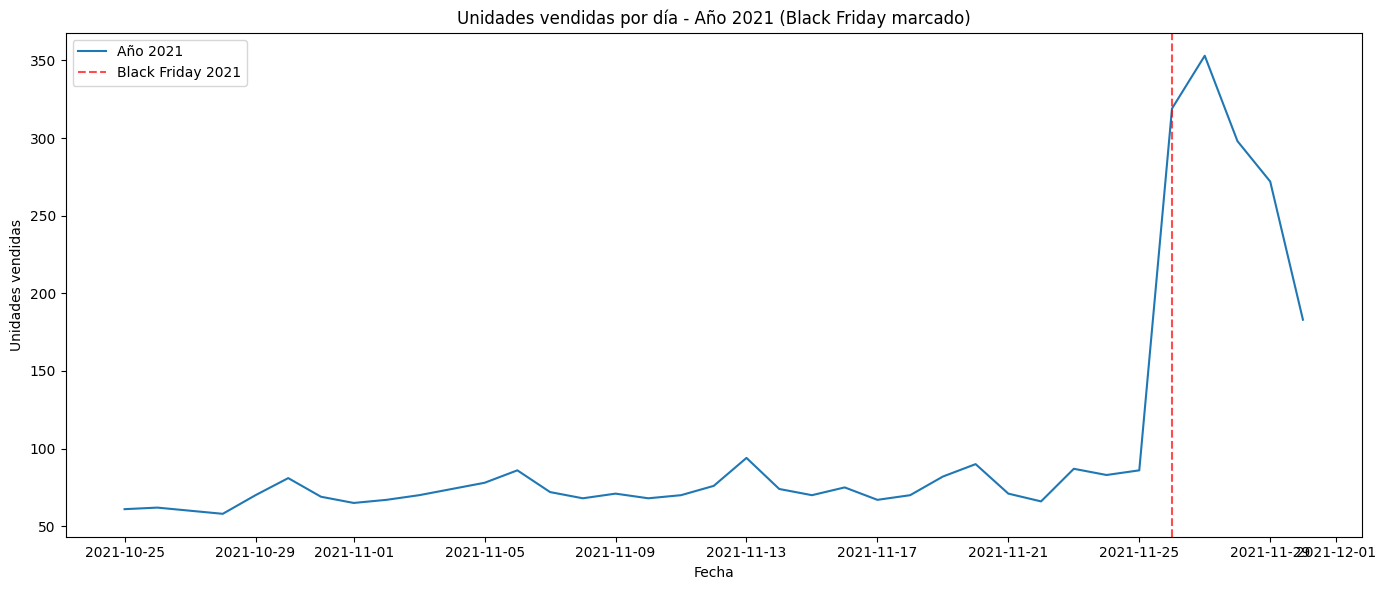

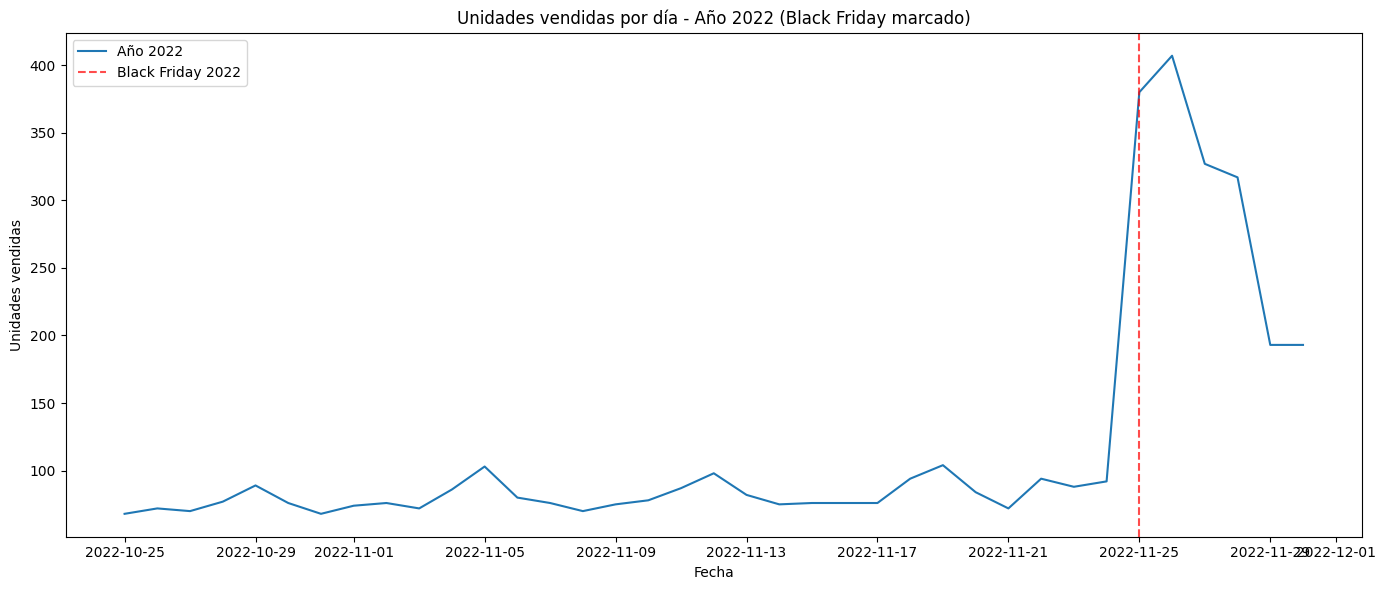

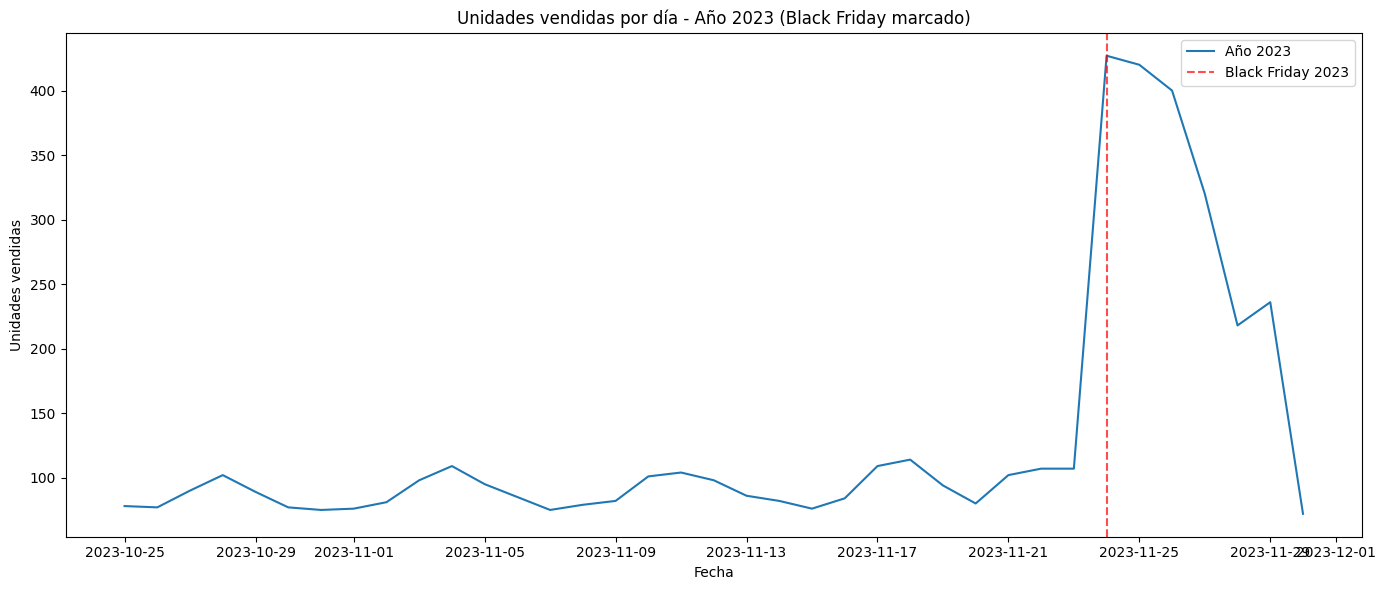

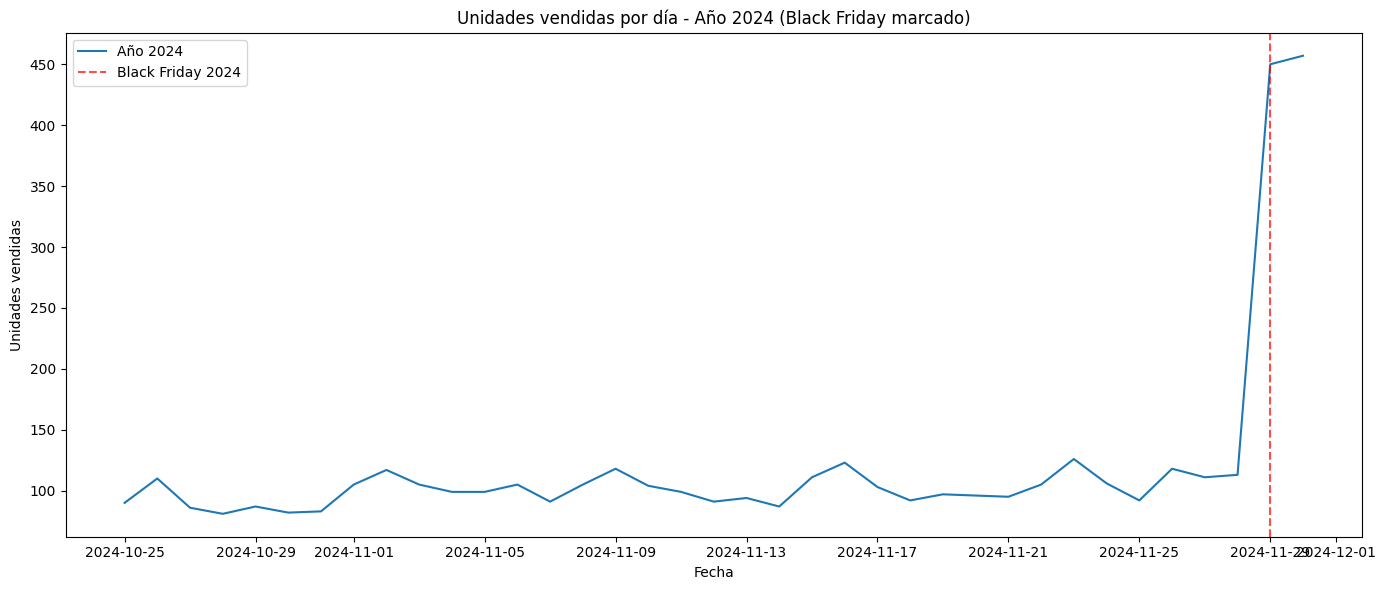

In [10]:
# 🤖 Gráfico de líneas temporales por año con Black Friday marcado (un gráfico por año)
import seaborn as sns
import matplotlib.pyplot as plt
df = dataframe_unified.copy()
df['año'] = df['fecha'].dt.year
df['dia'] = df['fecha'].dt.date
# Sumar unidades vendidas por día
ventas_por_dia = df.groupby(['dia','año'])['unidades_vendidas'].sum().reset_index()
# Identificar Black Friday (último viernes de noviembre)
def get_black_friday(year):
    nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    fridays = [d for d in nov if d.weekday() == 4]
    return fridays[-1].date()
black_fridays = {a:get_black_friday(a) for a in ventas_por_dia['año'].unique()}
# Un gráfico por cada año
for año in ventas_por_dia['año'].unique():
    datos = ventas_por_dia[ventas_por_dia['año']==año]
    plt.figure(figsize=(14,6))
    sns.lineplot(x='dia', y='unidades_vendidas', data=datos, label=f'Año {año}')
    bf = black_fridays[año]
    plt.axvline(bf, color='red', linestyle='--', alpha=0.7, label=f'Black Friday {año}')
    plt.title(f'Unidades vendidas por día - Año {año} (Black Friday marcado)')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Suma de unidades vendidas por día de la semana
Visualización de la suma de unidades vendidas agrupadas por el día de la semana.

/tmp/claude-0/ipykernel_2096/2727802638.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_dia_semana.index, y=ventas_por_dia_semana.values, palette='viridis')


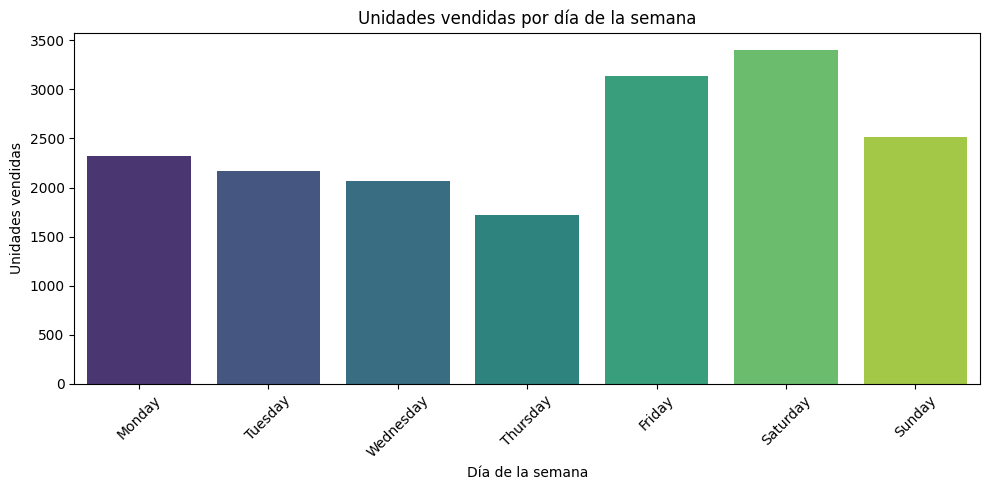

In [11]:
# 🤖 Suma de unidades vendidas por día de la semana
df = dataframe_unified.copy()
df['dia_semana'] = df['fecha'].dt.day_name()
ventas_por_dia_semana = df.groupby('dia_semana')['unidades_vendidas'].sum().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
], fill_value=0)
plt.figure(figsize=(10,5))
sns.barplot(x=ventas_por_dia_semana.index, y=ventas_por_dia_semana.values, palette='viridis')
plt.title('Unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Suma de unidades vendidas por categoría
Visualización de la suma de unidades vendidas agrupadas por categoría.

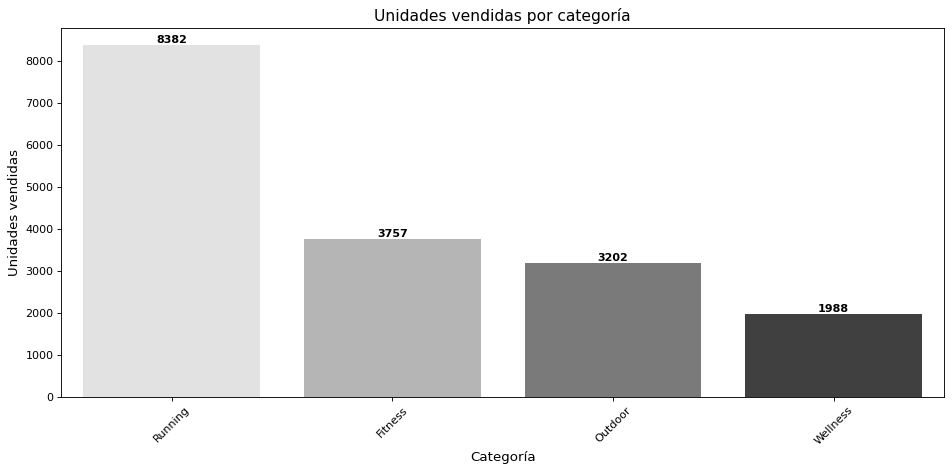

In [12]:
# 🤖 Suma de unidades vendidas por categoría (optimizado)
ventas_por_categoria = dataframe_unified.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6), dpi=80)
ax = sns.barplot(x=ventas_por_categoria.index, y=ventas_por_categoria.values, 
                 hue=ventas_por_categoria.index, palette='Greys', legend=False)

# Añadir etiquetas con números absolutos en cada barra
for i, (categoria, valor) in enumerate(zip(ventas_por_categoria.index, ventas_por_categoria.values)):
    ax.text(i, valor, str(int(valor)), ha='center', va='bottom', fontweight='bold')

plt.title('Unidades vendidas por categoría', fontsize=14)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Unidades vendidas', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

### Suma de unidades vendidas por subcategoría
Visualización de la suma de unidades vendidas agrupadas por subcategoría.

/tmp/claude-0/ipykernel_2096/2083543900.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_subcategoria.index, y=ventas_por_subcategoria.values, palette='mako')


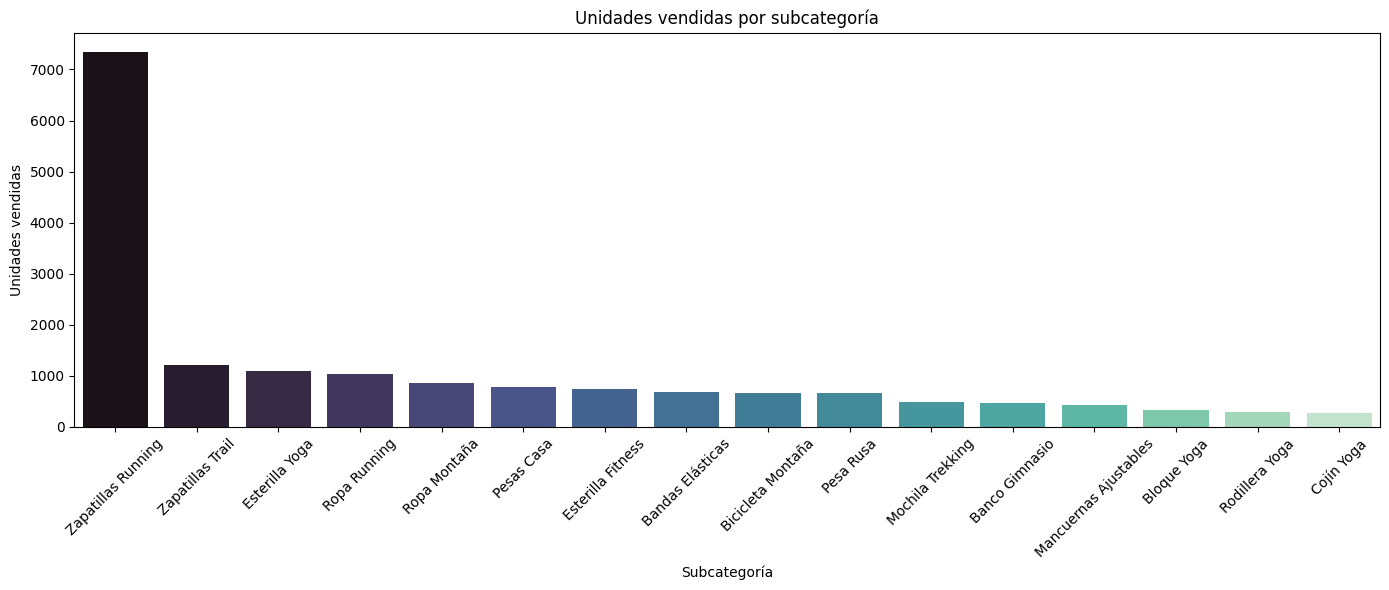

In [13]:
# 🤖 Suma de unidades vendidas por subcategoría
df = dataframe_unified.copy()
ventas_por_subcategoria = df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False)
plt.figure(figsize=(14,6))
sns.barplot(x=ventas_por_subcategoria.index, y=ventas_por_subcategoria.values, palette='mako')
plt.title('Unidades vendidas por subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Suma de unidades vendidas por producto (Top productos)
Visualización de los productos con mayor cantidad de unidades vendidas.

/tmp/claude-0/ipykernel_2096/3365129774.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='nombre', y='unidades_vendidas', data=ventas_por_producto, palette='rocket')


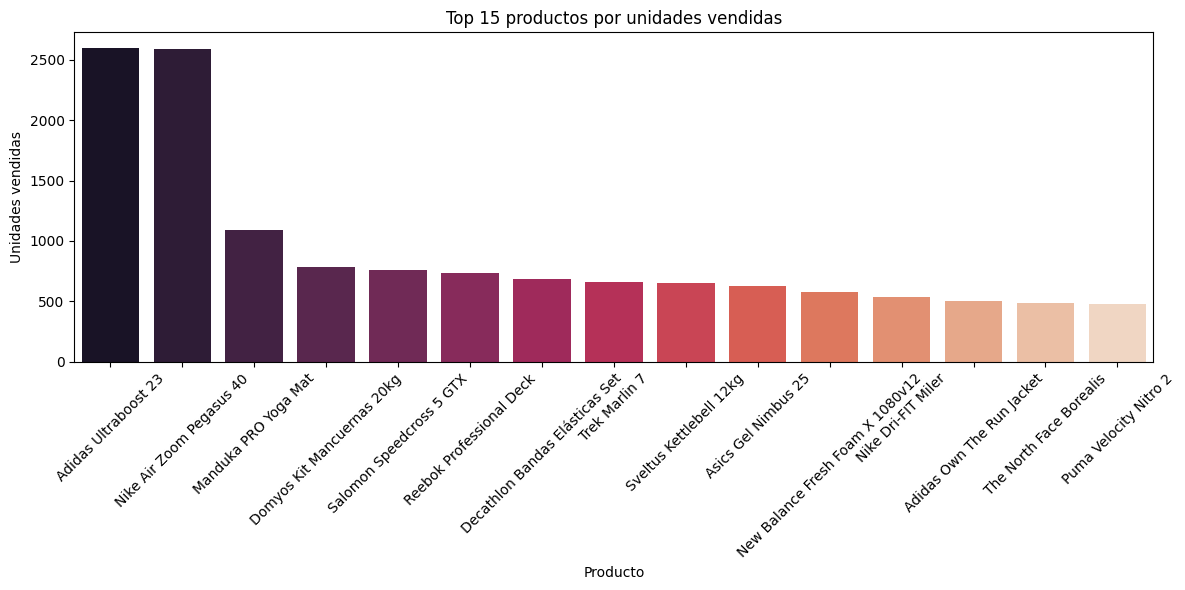

In [14]:
# 🤖 Top productos por unidades vendidas
df = dataframe_unified.copy()
top_n = 15
ventas_por_producto = df.groupby(['producto_id','nombre'])['unidades_vendidas'].sum().sort_values(ascending=False).head(top_n).reset_index()
plt.figure(figsize=(12,6))
sns.barplot(x='nombre', y='unidades_vendidas', data=ventas_por_producto, palette='rocket')
plt.title(f'Top {top_n} productos por unidades vendidas')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Densidad de distribución de precios (nuestros vs Amazon)
Comparativa de la densidad de precios de venta propios frente a los precios de Amazon como referencia de la competencia.

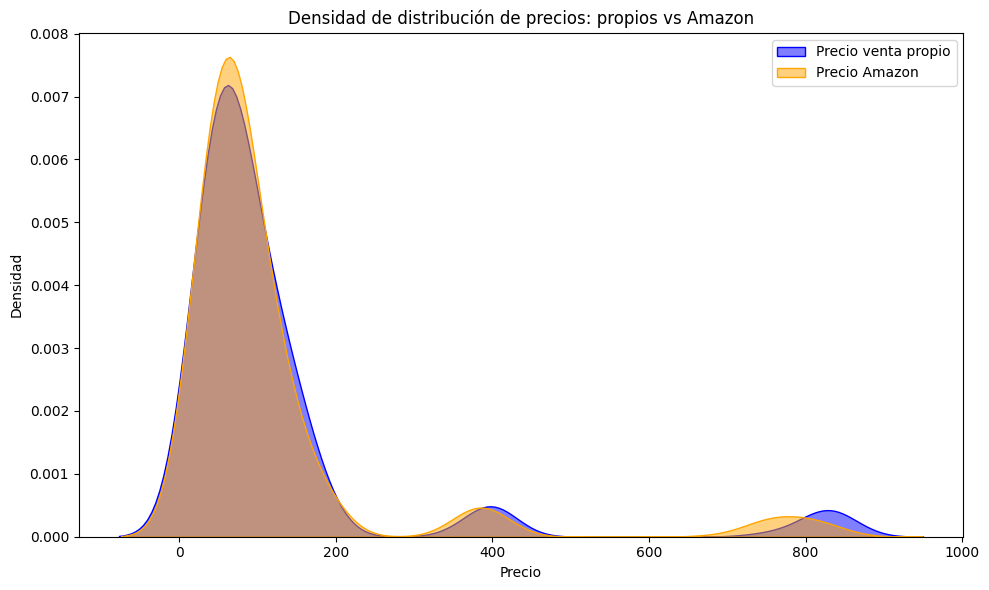

In [15]:
# 🤖 Densidad de distribución de precios: nuestros vs Amazon
df = dataframe_unified.copy()
plt.figure(figsize=(10,6))
sns.kdeplot(df['precio_venta'], label='Precio venta propio', fill=True, color='blue', alpha=0.5)
sns.kdeplot(df['Amazon'], label='Precio Amazon', fill=True, color='orange', alpha=0.5)
plt.title('Densidad de distribución de precios: propios vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

## Ingeniería de características temporales
Creación de variables temporales y de calendario para análisis avanzados:
- Variables básicas: año, mes, día del mes, día de la semana
- Indicadores festivos: es_festivo, es_fin_semana
- Eventos especiales: es_Black_Friday, es_Cyber_Monday
- Variables derivadas: trimestre, semana del año, número de días en el mes, es_puente
- Indicadores relativos: días_hasta_fin_mes, días_hasta_fin_trimestre

In [16]:
# 🤖 Crear variables temporales y de calendario
import holidays as hol
from dateutil.relativedelta import relativedelta

# Obtener calendario de festivos de España
spanish_holidays = hol.Spain()

# Crear copia del dataframe para las nuevas variables
df_temporal = dataframe_unified.copy()

# Variables básicas de fecha
df_temporal['año'] = df_temporal['fecha'].dt.year
df_temporal['mes'] = df_temporal['fecha'].dt.month
df_temporal['dia_mes'] = df_temporal['fecha'].dt.day
df_temporal['dia_semana'] = df_temporal['fecha'].dt.day_name()
df_temporal['dia_semana_num'] = df_temporal['fecha'].dt.dayofweek  # 0=lunes, 6=domingo

# Variables derivadas
df_temporal['trimestre'] = df_temporal['fecha'].dt.quarter
df_temporal['semana_ano'] = df_temporal['fecha'].dt.isocalendar().week
df_temporal['num_dias_mes'] = df_temporal['fecha'].dt.daysinmonth

# Indicadores de fin de semana
df_temporal['es_fin_semana'] = df_temporal['dia_semana_num'].isin([5, 6]).astype(int)

# Indicador de festivo
df_temporal['es_festivo'] = df_temporal['fecha'].apply(lambda x: 1 if x in spanish_holidays else 0)

# Variables de eventos especiales
# Black Friday: último viernes de noviembre
df_temporal['es_Black_Friday'] = 0
for year in df_temporal['año'].unique():
    noviembre = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    black_friday_date = [d.date() for d in noviembre if d.weekday() == 4][-1]
    df_temporal.loc[df_temporal['fecha'].dt.date == black_friday_date, 'es_Black_Friday'] = 1

# Cyber Monday: primer lunes después del Black Friday
df_temporal['es_Cyber_Monday'] = 0
for year in df_temporal['año'].unique():
    noviembre = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    black_friday_date = [d for d in noviembre if d.weekday() == 4][-1]
    cyber_monday_date = black_friday_date + pd.Timedelta(days=3)  # Miércoles después del BF
    df_temporal.loc[df_temporal['fecha'].dt.date == cyber_monday_date.date(), 'es_Cyber_Monday'] = 1

# Año nuevo, Navidad y días alrededor
df_temporal['es_Navidad'] = ((df_temporal['mes'] == 12) & (df_temporal['dia_mes'].isin([24, 25, 26]))).astype(int)
df_temporal['es_Ano_Nuevo'] = ((df_temporal['mes'] == 1) & (df_temporal['dia_mes'].isin([1, 2, 3]))).astype(int)
df_temporal['es_Verano'] = df_temporal['mes'].isin([7, 8]).astype(int)

# Indicador de puente (viernes previo a festivo o lunes posterior)
df_temporal['es_puente'] = 0
for idx, row in df_temporal.iterrows():
    fecha = row['fecha']
    fecha_anterior = fecha - pd.Timedelta(days=1)
    fecha_siguiente = fecha + pd.Timedelta(days=1)
    if (fecha_anterior in spanish_holidays or fecha_siguiente in spanish_holidays):
        if row['dia_semana_num'] in [4, 0]:  # viernes o lunes
            df_temporal.loc[idx, 'es_puente'] = 1

# Días hasta fin de mes
df_temporal['dias_hasta_fin_mes'] = (df_temporal['fecha'].dt.daysinmonth - df_temporal['dia_mes']).astype(int)

# Días hasta fin de trimestre
def dias_hasta_fin_trimestre(fecha):
    if fecha.quarter == 1:
        fin_trimestre = pd.Timestamp(f'{fecha.year}-03-31')
    elif fecha.quarter == 2:
        fin_trimestre = pd.Timestamp(f'{fecha.year}-06-30')
    elif fecha.quarter == 3:
        fin_trimestre = pd.Timestamp(f'{fecha.year}-09-30')
    else:
        fin_trimestre = pd.Timestamp(f'{fecha.year}-12-31')
    return (fin_trimestre - fecha).days

df_temporal['dias_hasta_fin_trimestre'] = df_temporal['fecha'].apply(dias_hasta_fin_trimestre)

# Días hasta fin de año
df_temporal['dias_hasta_fin_ano'] = df_temporal['fecha'].apply(lambda x: (pd.Timestamp(f'{x.year}-12-31') - x).days)

temporal_cols = ['año', 'mes', 'dia_mes', 'dia_semana', 'dia_semana_num', 'trimestre', 'semana_ano',
                 'num_dias_mes', 'es_fin_semana', 'es_festivo', 'es_Black_Friday', 'es_Cyber_Monday',
                 'es_Navidad', 'es_Ano_Nuevo', 'es_Verano', 'es_puente', 'dias_hasta_fin_mes',
                 'dias_hasta_fin_trimestre', 'dias_hasta_fin_ano']

# Mostrar resumen de las nuevas variables
print('=== RESUMEN DE VARIABLES TEMPORALES CREADAS ===')
print(f'Total de filas: {len(df_temporal)}')
print(f'Nuevas columnas creadas: {len(temporal_cols)}')

# Tabla con primeras filas
display(df_temporal[['fecha'] + temporal_cols].head(10))

# Distribución de eventos especiales
print(f'\nDistribución de eventos especiales:')
print(f'  Black Friday: {df_temporal["es_Black_Friday"].sum()} días')
print(f'  Cyber Monday: {df_temporal["es_Cyber_Monday"].sum()} días')
print(f'  Festivos: {df_temporal["es_festivo"].sum()} días')
print(f'  Fines de semana: {df_temporal["es_fin_semana"].sum()} días')
print(f'  Puentes: {df_temporal["es_puente"].sum()} días')
print(f'  Navidad: {df_temporal["es_Navidad"].sum()} días')
print(f'  Año Nuevo: {df_temporal["es_Ano_Nuevo"].sum()} días')
print(f'  Verano: {df_temporal["es_Verano"].sum()} días')

print('\n✓ Variables temporales creadas correctamente.')

=== RESUMEN DE VARIABLES TEMPORALES CREADAS ===
Total de filas: 3552
Nuevas columnas creadas: 19


,fecha,año,mes,dia_mes,dia_semana,dia_semana_num,trimestre,semana_ano,num_dias_mes,es_fin_semana,es_festivo,es_Black_Friday,es_Cyber_Monday,es_Navidad,es_Ano_Nuevo,es_Verano,es_puente,dias_hasta_fin_mes,dias_hasta_fin_trimestre,dias_hasta_fin_ano
0,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
1,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
2,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
3,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
4,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
5,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
6,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
7,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
8,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
9,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67



Distribución de eventos especiales:
  Black Friday: 96 días
  Cyber Monday: 72 días
  Festivos: 96 días
  Fines de semana: 984 días
  Puentes: 24 días
  Navidad: 0 días
  Año Nuevo: 0 días
  Verano: 0 días

✓ Variables temporales creadas correctamente.


In [17]:
# 🤖 Crear lags de unidades vendidas (1 a 7) y media móvil de 7 días, POR PRODUCTO
# Usamos df_temporal generado en la celda anterior

df_lags = df_temporal.copy()

# Ordenar por PRODUCTO y fecha: cada serie temporal pertenece a un único producto.
# (Antes se ordenaba solo por año, lo que mezclaba ventas de productos distintos.)
df_lags = df_lags.sort_values(['producto_id', 'fecha']).reset_index(drop=True)

# Lags por producto: la venta de hace N días del MISMO producto (no de otro)
for lag in range(1, 8):
    df_lags[f'unidades_vendidas_lag{lag}'] = (
        df_lags.groupby('producto_id')['unidades_vendidas'].shift(lag)
    )

# Media móvil de 7 días por producto, desplazada 1 día con .shift(1) para NO incluir
# el día actual y así evitar fuga del target (mismo criterio que el notebook de inferencia)
df_lags['unidades_vendidas_ma7'] = (
    df_lags.groupby('producto_id')['unidades_vendidas']
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean().shift(1))
)

# Eliminar registros con nulos en cualquiera de las nuevas variables
lag_cols = [f'unidades_vendidas_lag{lag}' for lag in range(1,8)] + ['unidades_vendidas_ma7']
df_lags = df_lags.dropna(subset=lag_cols).reset_index(drop=True)

# Mostrar primeras filas para ver resultado
df_lags[['fecha', 'producto_id', 'unidades_vendidas'] + lag_cols].head(10)

,fecha,producto_id,unidades_vendidas,unidades_vendidas_lag1,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_ma7
0,2021-11-01,PROD_001,7,9.0,12.0,12.0,7.0,8.0,8.0,6.0,8.857143
1,2021-11-02,PROD_001,10,7.0,9.0,12.0,12.0,7.0,8.0,8.0,9.000000
2,2021-11-03,PROD_001,11,10.0,7.0,9.0,12.0,12.0,7.0,8.0,9.285714
3,2021-11-04,PROD_001,12,11.0,10.0,7.0,9.0,12.0,12.0,7.0,9.714286
4,2021-11-05,PROD_001,10,12.0,11.0,10.0,7.0,9.0,12.0,12.0,10.428571
5,2021-11-06,PROD_001,10,10.0,12.0,11.0,10.0,7.0,9.0,12.0,10.142857
6,2021-11-07,PROD_001,10,10.0,10.0,12.0,11.0,10.0,7.0,9.0,9.857143
7,2021-11-08,PROD_001,9,10.0,10.0,10.0,12.0,11.0,10.0,7.0,10.000000
8,2021-11-09,PROD_001,11,9.0,10.0,10.0,10.0,12.0,11.0,10.0,10.285714
9,2021-11-10,PROD_001,10,11.0,9.0,10.0,10.0,10.0,12.0,11.0,10.428571


In [18]:
# 🤖 Crear variable descuento porcentaje
# Fórmula: ((precio_venta - precio_base) / precio_base) * 100
# Usamos df_lags generado en la celda anterior

df_lags['descuento_porcentaje'] = ((df_lags['precio_venta'] - df_lags['precio_base']) / df_lags['precio_base']) * 100

# Mostrar primeras filas para ver resultado
df_lags[['fecha', 'producto_id', 'año', 'precio_base', 'precio_venta', 'descuento_porcentaje']].head(10)

,fecha,producto_id,año,precio_base,precio_venta,descuento_porcentaje
0,2021-11-01,PROD_001,2021,115,115.07,0.060870
1,2021-11-02,PROD_001,2021,115,116.10,0.956522
2,2021-11-03,PROD_001,2021,115,114.58,-0.365217
3,2021-11-04,PROD_001,2021,115,112.23,-2.408696
4,2021-11-05,PROD_001,2021,115,113.81,-1.034783
5,2021-11-06,PROD_001,2021,115,117.80,2.434783
6,2021-11-07,PROD_001,2021,115,116.04,0.904348
7,2021-11-08,PROD_001,2021,115,113.46,-1.339130
8,2021-11-09,PROD_001,2021,115,113.98,-0.886957
9,2021-11-10,PROD_001,2021,115,117.57,2.234783


In [19]:
# 🤖 Crear variable precio_competencia y ratio_precio, y eliminar columnas de competidores
# Calcular precio promedio de Amazon, Decathlon y Deporvillage

df_lags['precio_competencia'] = df_lags[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)

# Crear ratio de nuestro precio respecto al precio promedio de la competencia
# ratio_precio = precio_venta / precio_competencia

df_lags['ratio_precio'] = df_lags['precio_venta'] / df_lags['precio_competencia']

# Eliminar las columnas de los competidores
cols_drop = ['Amazon', 'Decathlon', 'Deporvillage']
df_lags = df_lags.drop(columns=cols_drop)

# Mostrar primeras filas para ver resultado
df_lags[['fecha', 'producto_id', 'año', 'precio_venta', 'precio_competencia', 'ratio_precio']].head(10)

,fecha,producto_id,año,precio_venta,precio_competencia,ratio_precio
0,2021-11-01,PROD_001,2021,115.07,95.353333,1.206775
1,2021-11-02,PROD_001,2021,116.10,96.153333,1.207446
2,2021-11-03,PROD_001,2021,114.58,95.240000,1.203066
3,2021-11-04,PROD_001,2021,112.23,96.590000,1.161922
4,2021-11-05,PROD_001,2021,113.81,96.170000,1.183425
5,2021-11-06,PROD_001,2021,117.80,95.436667,1.234326
6,2021-11-07,PROD_001,2021,116.04,96.153333,1.206822
7,2021-11-08,PROD_001,2021,113.46,97.003333,1.169651
8,2021-11-09,PROD_001,2021,113.98,96.933333,1.175860
9,2021-11-10,PROD_001,2021,117.57,96.343333,1.220323


In [20]:
df_lags.info()

<class 'pandas.DataFrame'>
RangeIndex: 3384 entries, 0 to 3383
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fecha                     3384 non-null   datetime64[us]
 1   producto_id               3384 non-null   str           
 2   nombre                    3384 non-null   str           
 3   categoria                 3384 non-null   str           
 4   subcategoria              3384 non-null   str           
 5   precio_base               3384 non-null   int64         
 6   es_estrella               3384 non-null   bool          
 7   unidades_vendidas         3384 non-null   int64         
 8   precio_venta              3384 non-null   float64       
 9   ingresos                  3384 non-null   float64       
 10  año                       3384 non-null   int32         
 11  mes                       3384 non-null   int32         
 12  dia_mes                   3384 

In [21]:
# 🤖 Crear copias *_h y aplicar One-Hot Encoding sobre ellas
# Copiar columnas con sufijo _h
df_lags['nombre_h'] = df_lags['nombre']
df_lags['categoria_h'] = df_lags['categoria']
df_lags['subcategoria_h'] = df_lags['subcategoria']

# One-Hot Encoding (usamos prefijos que incluyan _h para distinguir)
ohe_cols = ['nombre_h','categoria_h','subcategoria_h']
df_ohe = pd.get_dummies(df_lags[ohe_cols].astype(str), prefix=['nombre_h','categoria_h','subcategoria_h'], dtype=int)

# Concatenar las columnas OHE al dataframe principal
df_lags = pd.concat([df_lags, df_ohe], axis=1)

# Comprobación rápida: mostrar las nuevas columnas OHE y primeras filas
print('Número de columnas OHE añadidas:', df_ohe.shape[1])
print('Ejemplo de columnas OHE (primeras 10):', df_ohe.columns.tolist()[:10])
df_lags[['fecha','producto_id','año'] + df_ohe.columns.tolist()[:10]].head()

Número de columnas OHE añadidas: 44
Ejemplo de columnas OHE (primeras 10): ['nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23', 'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552', 'nombre_h_Columbia Silver Ridge', 'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900', 'nombre_h_Domyos Kit Mancuernas 20kg', 'nombre_h_Gaiam Premium Yoga Block', 'nombre_h_Liforme Yoga Pad']


,fecha,producto_id,año,nombre_h_Adidas Own The Run Jacket,nombre_h_Adidas Ultraboost 23,nombre_h_Asics Gel Nimbus 25,nombre_h_Bowflex SelectTech 552,nombre_h_Columbia Silver Ridge,nombre_h_Decathlon Bandas Elásticas Set,nombre_h_Domyos BM900,nombre_h_Domyos Kit Mancuernas 20kg,nombre_h_Gaiam Premium Yoga Block,nombre_h_Liforme Yoga Pad
0,2021-11-01,PROD_001,2021,0,0,0,0,0,0,0,0,0,0
1,2021-11-02,PROD_001,2021,0,0,0,0,0,0,0,0,0,0
2,2021-11-03,PROD_001,2021,0,0,0,0,0,0,0,0,0,0
3,2021-11-04,PROD_001,2021,0,0,0,0,0,0,0,0,0,0
4,2021-11-05,PROD_001,2021,0,0,0,0,0,0,0,0,0,0


In [22]:
# 🤖 Guardar `df_lags` (versión compacta)
from pathlib import Path

# Usamos df_temporal generado en la celda anterior

df_processed = df_lags.copy()

p=Path('../data/processed'); p.mkdir(parents=True, exist_ok=True); df_processed.to_csv(p/'df_processed.csv', index=False)
print('Guardado:', p/'df_processed.csv')


Guardado: ../data/processed/df_processed.csv


In [23]:
# 🤖 Dividir df_processed en train_df (2021-2023) y validation_df (2024)

# Verificar años disponibles en df_processed
print("Años disponibles en df_processed:", sorted(df_processed['año'].unique()))
print()

# Dividir por año
train_df = df_processed[df_processed['año'].isin([2021, 2022, 2023])].copy()
validation_df = df_processed[df_processed['año'] == 2024].copy()

# Mostrar conteos
print("="*60)
print("DIVISIÓN DE DATOS - TRAIN vs VALIDATION")
print("="*60)
print(f"\ntrain_df (años 2021-2023):")
print(f"  Registros: {len(train_df):,}")
print(f"  Años: {sorted(train_df['año'].unique())}")
print(f"  Rango de fechas: {train_df['fecha'].min()} a {train_df['fecha'].max()}")

print(f"\nvalidation_df (año 2024):")
print(f"  Registros: {len(validation_df):,}")
print(f"  Años: {sorted(validation_df['año'].unique())}")
print(f"  Rango de fechas: {validation_df['fecha'].min()} a {validation_df['fecha'].max()}")

print(f"\nTotal: {len(train_df) + len(validation_df):,} registros")
print(f"Proporción train/validation: {len(train_df)}/{len(validation_df)} ({100*len(train_df)/(len(train_df)+len(validation_df)):.1f}% / {100*len(validation_df)/(len(train_df)+len(validation_df)):.1f}%)")
print("="*60)


Años disponibles en df_processed: [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]

DIVISIÓN DE DATOS - TRAIN vs VALIDATION

train_df (años 2021-2023):
  Registros: 2,496
  Años: [np.int32(2021), np.int32(2022), np.int32(2023)]
  Rango de fechas: 2021-11-01 00:00:00 a 2023-11-30 00:00:00

validation_df (año 2024):
  Registros: 888
  Años: [np.int32(2024)]
  Rango de fechas: 2024-10-25 00:00:00 a 2024-11-30 00:00:00

Total: 3,384 registros
Proporción train/validation: 2496/888 (73.8% / 26.2%)


In [24]:
# 🤖 Entrenar HistGradientBoostingRegressor (conservador) y evaluar vs baseline naive
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Comprobar que train_df y validation_df existen
try:
    _ = train_df
    _ = validation_df
except NameError:
    raise NameError("Las variables `train_df` y `validation_df` no existen. Ejecuta la celda que divide `df_processed` primero.")

# Seleccionar columnas numéricas como predictoras (excluir target y 'ingresos')
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
predictors = [c for c in numeric_cols if c not in ['unidades_vendidas', 'ingresos']]

# Asegurar que las mismas columnas estén en validation_df
common_predictors = [c for c in predictors if c in validation_df.columns]
if len(common_predictors) != len(predictors):
    miss = set(predictors) - set(common_predictors)
    print(f"Advertencia: las siguientes columnas no están en validation_df y se excluyen: {sorted(list(miss))}")

if len(common_predictors) == 0:
    raise ValueError("No hay columnas numéricas comunes para usar como predictoras.")

X_train = train_df[common_predictors].copy()
y_train = train_df['unidades_vendidas'].copy()
X_val = validation_df[common_predictors].copy()
y_val = validation_df['unidades_vendidas'].copy()

# Imputación simple: medianas del train
medianas = X_train.median()
X_train = X_train.fillna(medianas)
X_val = X_val.fillna(medianas)

# Baseline naive: predecir la media de y_train
y_mean = y_train.mean()
y_pred_baseline = np.full(shape=len(y_val), fill_value=y_mean)

# Definir y entrenar HistGradientBoostingRegressor con parámetros conservadores
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=1000,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

print('\nEntrenando HistGradientBoostingRegressor (puede tardar unos segundos)...')
model.fit(X_train, y_train)
print('Entrenamiento completado.')

# Predicciones
y_pred = model.predict(X_val)

# Métricas
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

# MAPE (evitar división por cero)
def mape(a, b):
    denom = np.where(a == 0, 1e-8, a)
    return np.mean(np.abs((a - b) / denom)) * 100

mape_val = mape(y_val.values, y_pred)

# Métricas baseline
mae_base = mean_absolute_error(y_val, y_pred_baseline)
mse_base = mean_squared_error(y_val, y_pred_baseline)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(y_val, y_pred_baseline)
mape_base = mape(y_val.values, y_pred_baseline)

# Mostrar resultados
print('\n' + '='*60)
print('EVALUACIÓN EN VALIDATION (año 2024)')
print('='*60)
print('\nModel: HistGradientBoostingRegressor (conservador)')
print(f'  Registros validación: {len(y_val):,}')
print(f'  MAE:  {mae:,.4f}')
print(f'  RMSE: {rmse:,.4f}')
print(f'  MAPE: {mape_val:,.2f}%')
print(f'  R2:   {r2:,.4f}')

print('\nBaseline naive (predice la media del train)')
print(f'  MAE:  {mae_base:,.4f}')
print(f'  RMSE: {rmse_base:,.4f}')
print(f'  MAPE: {mape_base:,.2f}%')
print(f'  R2:   {r2_base:,.4f}')
print('\n' + '='*60)

# Comparativa relativa (mejora sobre baseline en MAE y RMSE)
impr_mae = (mae_base - mae) / mae_base * 100 if mae_base != 0 else np.nan
impr_rmse = (rmse_base - rmse) / rmse_base * 100 if rmse_base != 0 else np.nan
print(f'Improv. MAE vs baseline: {impr_mae:.2f}%')
print(f'Improv. RMSE vs baseline: {impr_rmse:.2f}%')
print('\nRecomendación rápida: revisar MAPE y R2; si R2 es muy bajo o hay sobreajuste, ajustar regularización/feature engineering.')



Entrenando HistGradientBoostingRegressor (puede tardar unos segundos)...


Entrenamiento completado.

EVALUACIÓN EN VALIDATION (año 2024)

Model: HistGradientBoostingRegressor (conservador)
  Registros validación: 888
  MAE:  0.8841
  RMSE: 1.6492
  MAPE: 18.28%
  R2:   0.9303

Baseline naive (predice la media del train)
  MAE:  3.4198
  RMSE: 6.2480
  MAPE: 90.53%
  R2:   -0.0000

Improv. MAE vs baseline: 74.15%
Improv. RMSE vs baseline: 73.60%

Recomendación rápida: revisar MAPE y R2; si R2 es muy bajo o hay sobreajuste, ajustar regularización/feature engineering.


Se generarán gráficos para 7 productos estrella: ['PROD_001', 'PROD_002', 'PROD_009', 'PROD_010', 'PROD_015', 'PROD_016', 'PROD_021']


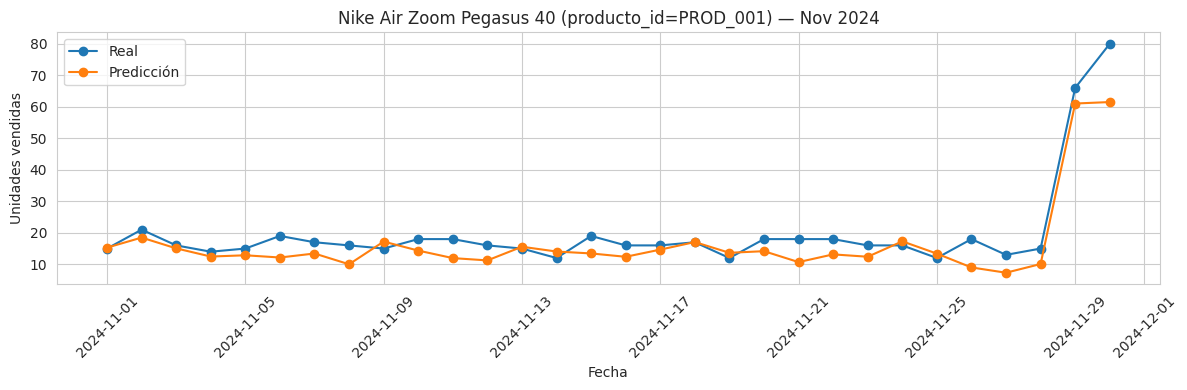

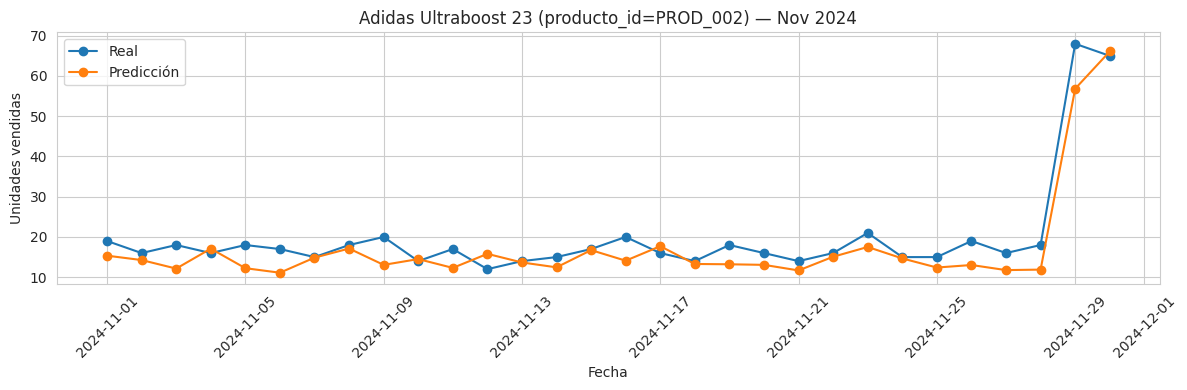

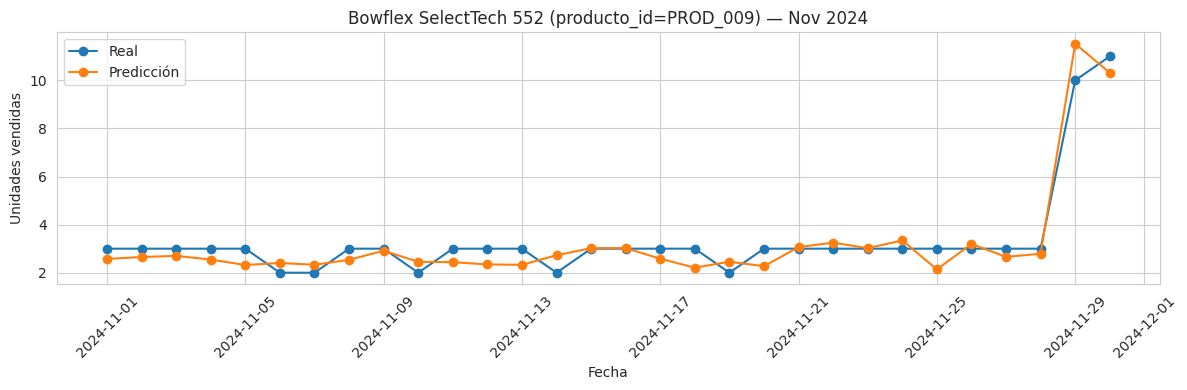

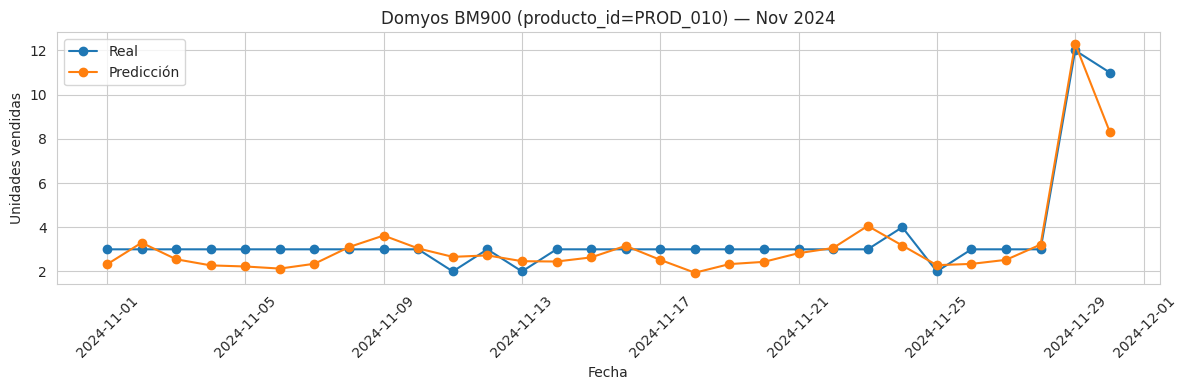

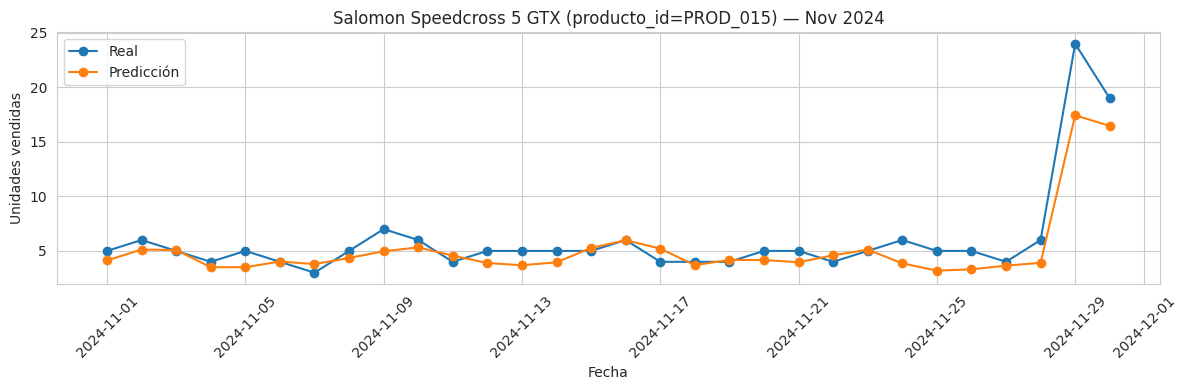

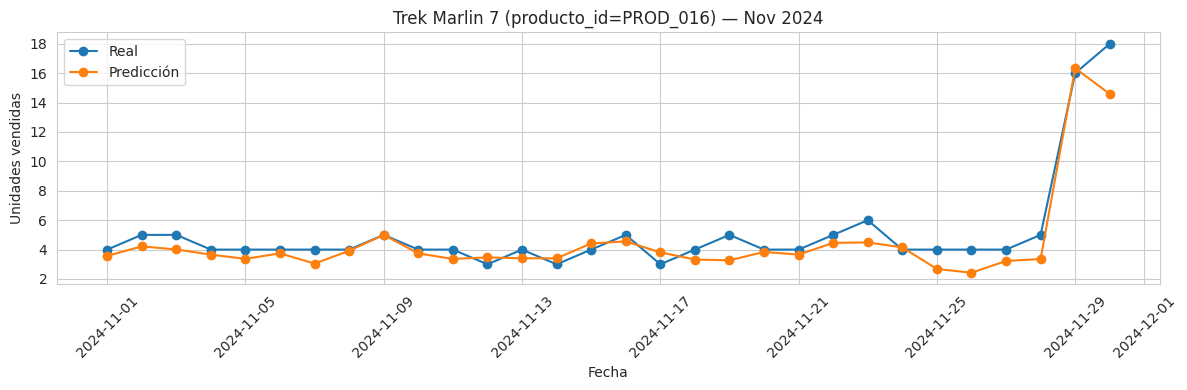

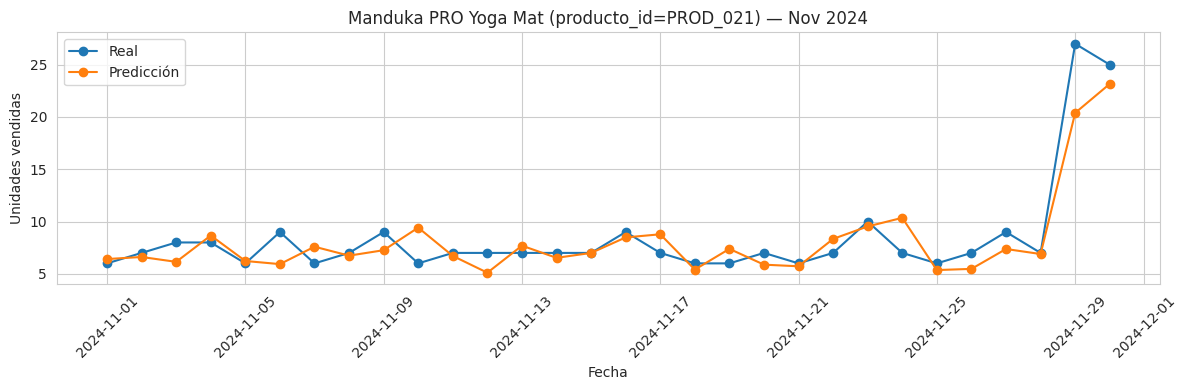


¡Listo! Se mostraron los gráficos en el notebook.


In [25]:
# 🤖 Predicciones para noviembre 2024 de 7 productos estrella y gráficos comparativos
import matplotlib.pyplot as plt
import seaborn as sns

# Comprobar variables necesarias
if 'model' not in globals():
    raise NameError('La variable `model` (modelo entrenado) no está definida. Ejecuta la celda de entrenamiento antes.')

# Determinar predictoras numéricas (misma lógica que antes)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
predictors = [c for c in numeric_cols if c not in ['unidades_vendidas', 'ingresos']]
common_predictors = [c for c in predictors if c in df_processed.columns]
if len(common_predictors) == 0:
    raise ValueError('No hay columnas numéricas comunes para usar como predictoras.')

# Medianas para imputación (si no existe variable, recalcular desde train_df)
if 'medianas' in globals():
    med = medianas
else:
    med = train_df[common_predictors].median()

# Filtrar noviembre 2024 y sólo productos estrella
nov = df_processed[(df_processed['año'] == 2024) & (df_processed['mes'] == 11) & (df_processed['es_estrella'] == 1)].copy()

if nov.empty:
    print('No se encontraron registros de noviembre 2024 con `es_estrella==1`.')
else:
    # Seleccionar hasta 7 productos distintos
    productos = list(nov['producto_id'].unique())[:7]
    print(f'Se generarán gráficos para {len(productos)} productos estrella: {productos}')

    sns.set_style('whitegrid')
    for pid in productos:
        rows = nov[nov['producto_id'] == pid].sort_values('fecha')
        if rows.empty:
            continue
        # Comprobar que tenga suficientes filas para graficar
        if len(rows) < 1:
            print(f'Skipping producto {pid}: no hay filas suficientes.')
            continue

        # Preparar X
        missing_cols = [c for c in common_predictors if c not in rows.columns]
        if missing_cols:
            print(f'Advertencia: producto {pid} no tiene columnas {missing_cols} - se omite.')
            continue

        Xp = rows[common_predictors].copy().fillna(med)
        y_true = rows['unidades_vendidas'].values
        try:
            y_pred = model.predict(Xp)
        except Exception as e:
            print(f'Error al predecir para producto {pid}: {e}')
            continue

        nombre = rows['nombre'].iloc[0] if 'nombre' in rows.columns else f'producto_{pid}'

        plt.figure(figsize=(12,4))
        plt.plot(rows['fecha'], y_true, label='Real', marker='o')
        plt.plot(rows['fecha'], y_pred, label='Predicción', marker='o')
        plt.title(f'{nombre} (producto_id={pid}) — Nov 2024')
        plt.xlabel('Fecha')
        plt.ylabel('Unidades vendidas')
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()

print('\n¡Listo! Se mostraron los gráficos en el notebook.')


In [26]:
# 🤖 Calcular MAE por producto estrella para noviembre 2024
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Verificaciones básicas
if 'model' not in globals():
    raise NameError('La variable `model` no está disponible. Ejecuta la celda de entrenamiento antes.')

# Definir predictoras (misma lógica que usamos antes)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
predictors = [c for c in numeric_cols if c not in ['unidades_vendidas', 'ingresos']]
common_predictors = [c for c in predictors if c in df_processed.columns]
if len(common_predictors) == 0:
    raise ValueError('No se encontraron columnas numéricas comunes para usar como predictoras.')

# Medianas para imputación
if 'medianas' in globals():
    med = medianas
else:
    med = train_df[common_predictors].median()

# Filtrar noviembre 2024 y productos estrella
nov = df_processed[(df_processed['año'] == 2024) & (df_processed['mes'] == 11) & (df_processed['es_estrella'] == 1)].copy()
if nov.empty:
    print('No hay datos de noviembre 2024 con es_estrella==1 en `df_processed`.')
else:
    productos = nov['producto_id'].unique()

    resultados = []
    for pid in productos:
        rows = nov[nov['producto_id'] == pid].sort_values('fecha')
        if rows.empty:
            continue
        # Preparar X
        Xp = rows[common_predictors].copy().fillna(med)
        y_true = rows['unidades_vendidas'].values
        try:
            y_pred = model.predict(Xp)
        except Exception as e:
            print(f'Error al predecir producto {pid}: {e}')
            continue

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        n = len(y_true)
        nombre = rows['nombre'].iloc[0] if 'nombre' in rows.columns else ''

        resultados.append({
            'producto_id': pid,
            'nombre': nombre,
            'n_registros': n,
            'MAE': mae,
            'RMSE': rmse
        })

    if len(resultados) == 0:
        print('No se calcularon métricas para ningún producto (posible falta de filas o errores de predicción).')
    else:
        df_res = pd.DataFrame(resultados).sort_values('MAE')
        # Mostrar con formato
        pd.options.display.float_format = '{:,.4f}'.format
        print('\nMAE por producto estrella (Nov 2024) — ordenado ascendente por MAE')
        display(df_res.reset_index(drop=True))
        print('\nResumen:')
        print(f"  Productos evaluados: {len(df_res)}")
        print(f"  MAE medio (por producto): {df_res['MAE'].mean():.4f}")

# Marca el TODO como completado (localmente) — no ejecuto manage_todo_list otra vez aquí.
print('\n✅ Cálculo completado. Si quieres, ejecuto también los gráficos o guardo la tabla como CSV.')



MAE por producto estrella (Nov 2024) — ordenado ascendente por MAE


,producto_id,nombre,n_registros,MAE,RMSE
0,PROD_009,Bowflex SelectTech 552,30,0.4497,0.5459
1,PROD_010,Domyos BM900,30,0.5735,0.7457
2,PROD_016,Trek Marlin 7,30,0.7554,1.0157
3,PROD_015,Salomon Speedcross 5 GTX,30,1.1254,1.6578
4,PROD_021,Manduka PRO Yoga Mat,30,1.3390,1.8989
5,PROD_002,Adidas Ultraboost 23,30,3.2768,4.1768
6,PROD_001,Nike Air Zoom Pegasus 40,30,4.0209,5.3291



Resumen:
  Productos evaluados: 7
  MAE medio (por producto): 1.6487

✅ Cálculo completado. Si quieres, ejecuto también los gráficos o guardo la tabla como CSV.



Métricas agregadas por periodo (Noviembre 2024, productos estrella)


,label,n,MAE,RMSE,MAPE
periodo,,,,,
1,1-10 Nov,70,1.3947,2.2227,16.1981
2,11-20 Nov,70,1.2766,1.9630,16.7090
3,21-30 Nov,70,2.2747,3.7928,18.0684


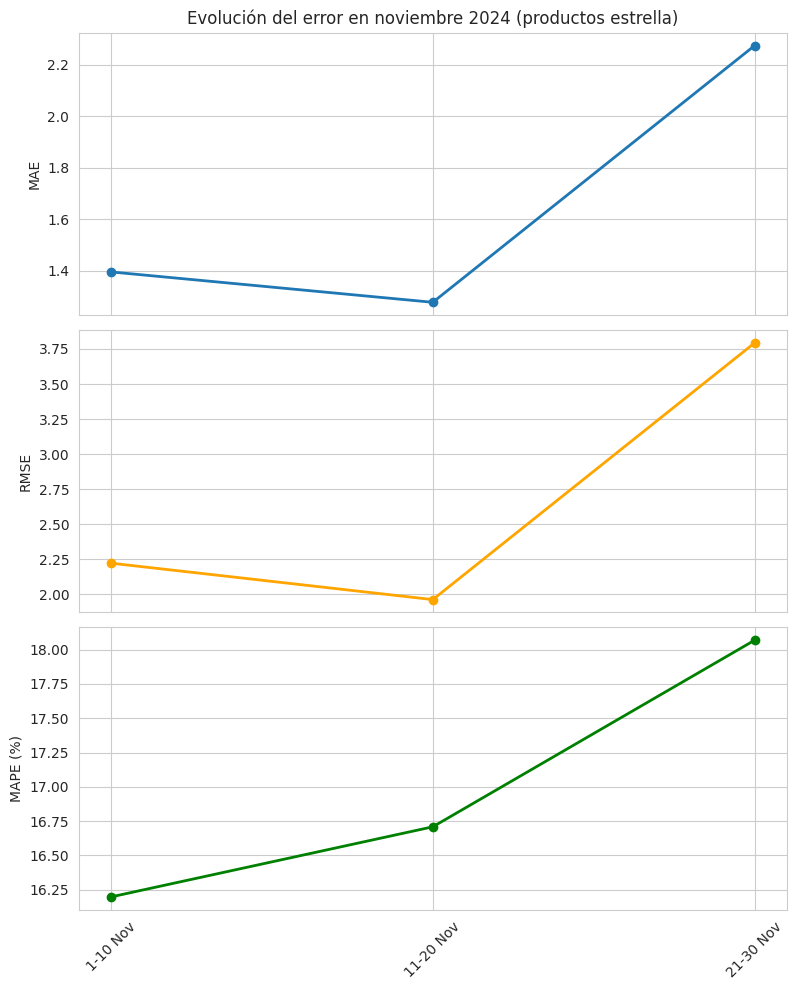


Resumen rápido:
  Periodos evaluados: 3
  Registros total en Nov: 210
  Observa la tendencia para decidir acciones (ej: recalibrar, más features, o regularización).

✅ Análisis por periodos completado.


In [27]:
# 🤖 Análisis de degradación del error en Noviembre 2024 (3 periodos de 10 días)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Verificaciones
if 'model' not in globals():
    raise NameError('La variable `model` no está disponible. Ejecuta la celda de entrenamiento antes.')

# Predictoras (misma lógica)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
predictors = [c for c in numeric_cols if c not in ['unidades_vendidas', 'ingresos']]
common_predictors = [c for c in predictors if c in df_processed.columns]
if len(common_predictors) == 0:
    raise ValueError('No hay columnas numéricas comunes para usar como predictoras.')

# Medianas para imputación
if 'medianas' in globals():
    med = medianas
else:
    med = train_df[common_predictors].median()

# Filtrar noviembre 2024 y solo productos estrella
nov = df_processed[(df_processed['año'] == 2024) & (df_processed['mes'] == 11) & (df_processed['es_estrella'] == 1)].copy()
if nov.empty:
    print('No hay datos de noviembre 2024 con es_estrella==1 en `df_processed`.')
else:
    # Asignar periodo: 1=1-10, 2=11-20, 3=21-30
    nov['dia'] = nov['fecha'].dt.day
    def periodo_de_dia(d):
        if d <= 10:
            return 1
        elif d <= 20:
            return 2
        else:
            return 3
    nov['periodo'] = nov['dia'].apply(periodo_de_dia)

    metrics = []
    for p in [1,2,3]:
        rows = nov[nov['periodo'] == p].sort_values('fecha')
        if rows.empty:
            metrics.append({'periodo': p, 'n': 0, 'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan})
            continue
        Xp = rows[common_predictors].copy().fillna(med)
        y_true = rows['unidades_vendidas'].values
        try:
            y_pred = model.predict(Xp)
        except Exception as e:
            print(f'Error al predecir periodo {p}: {e}')
            metrics.append({'periodo': p, 'n': len(y_true), 'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan})
            continue
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        # MAPE
        denom = np.where(y_true == 0, 1e-8, y_true)
        mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
        metrics.append({'periodo': p, 'n': len(y_true), 'MAE': mae, 'RMSE': rmse, 'MAPE': mape})

    df_metrics = pd.DataFrame(metrics).set_index('periodo')
    # Etiquetas legibles
    labels = {1: '1-10 Nov', 2: '11-20 Nov', 3: '21-30 Nov'}
    df_metrics['label'] = df_metrics.index.map(labels)

    pd.options.display.float_format = '{:,.4f}'.format
    print('\nMétricas agregadas por periodo (Noviembre 2024, productos estrella)')
    display(df_metrics[['label','n','MAE','RMSE','MAPE']])

    # Gráficas: evolución del MAE, RMSE y MAPE (subplots)
    sns.set_style('whitegrid')
    x = [1,2,3]
    xlabels = [labels[i] for i in x]

    fig, axes = plt.subplots(3,1, figsize=(8,10), sharex=True)

    axes[0].plot(x, df_metrics['MAE'].values, marker='o', linewidth=2)
    axes[0].set_ylabel('MAE')
    axes[0].set_title('Evolución del error en noviembre 2024 (productos estrella)')

    axes[1].plot(x, df_metrics['RMSE'].values, marker='o', color='orange', linewidth=2)
    axes[1].set_ylabel('RMSE')

    axes[2].plot(x, df_metrics['MAPE'].values, marker='o', color='green', linewidth=2)
    axes[2].set_ylabel('MAPE (%)')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(xlabels, rotation=45)

    plt.tight_layout()
    plt.show()

    # Mostrar resumen rápido
    print('\nResumen rápido:')
    print(f"  Periodos evaluados: {len(df_metrics)}")
    print(f"  Registros total en Nov: {df_metrics['n'].sum():,}")
    print('  Observa la tendencia para decidir acciones (ej: recalibrar, más features, o regularización).')

print('\n✅ Análisis por periodos completado.')


Black Friday 2024: 2024-11-29
Registros encontrados: 24


,producto_id,nombre,y_true,y_pred,abs_err
0,PROD_001,Nike Air Zoom Pegasus 40,66.0000,61.0371,4.9629
1,PROD_002,Adidas Ultraboost 23,68.0000,56.8334,11.1666
2,PROD_003,Asics Gel Nimbus 25,18.0000,12.5141,5.4859
3,PROD_004,New Balance Fresh Foam X 1080v12,14.0000,11.5792,2.4208
4,PROD_005,Nike Dri-FIT Miler,14.0000,10.1288,3.8712
5,PROD_006,Adidas Own The Run Jacket,12.0000,10.7353,1.2647
6,PROD_007,Puma Velocity Nitro 2,13.0000,6.6829,6.3171
7,PROD_008,Reebok Floatride Energy 5,12.0000,8.6188,3.3812
8,PROD_009,Bowflex SelectTech 552,10.0000,11.5229,1.5229
9,PROD_010,Domyos BM900,12.0000,12.3012,0.3012


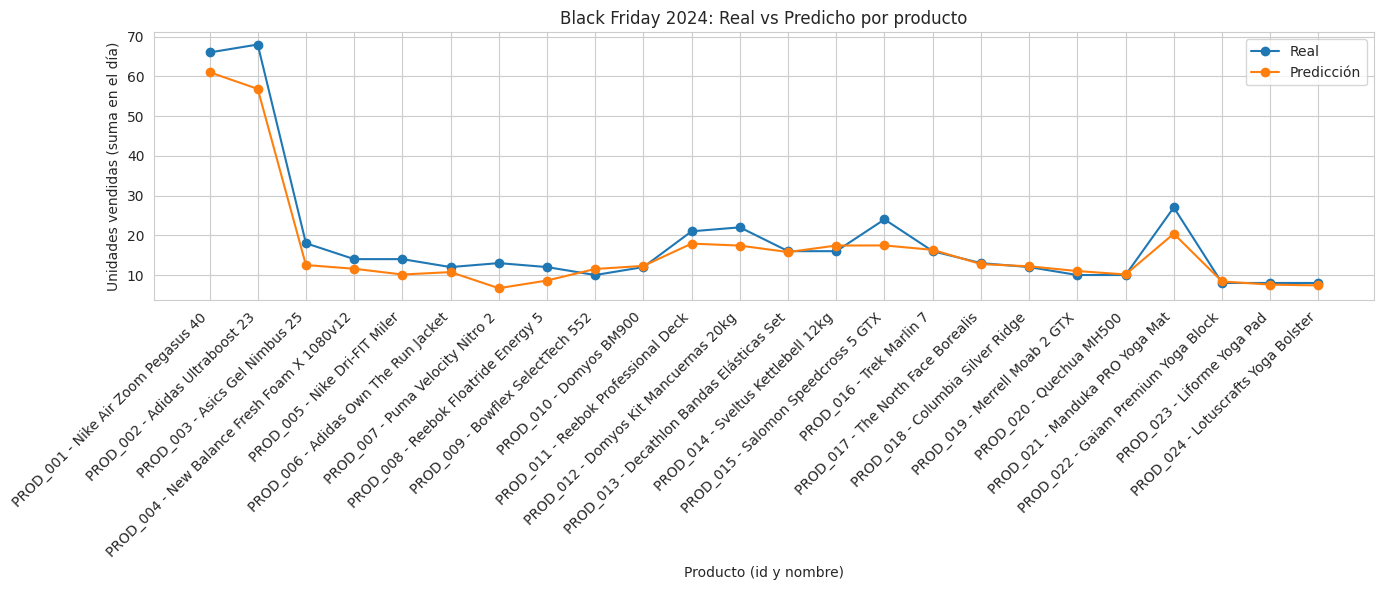

Guardado: ../reports/bf2024_real_vs_pred.csv  y  ../reports/figs/bf2024_real_vs_pred.png


,producto_id,nombre,y_true,y_pred,abs_err
0,PROD_002,Adidas Ultraboost 23,68.0000,56.8334,11.1666
1,PROD_021,Manduka PRO Yoga Mat,27.0000,20.3891,6.6109
2,PROD_015,Salomon Speedcross 5 GTX,24.0000,17.4450,6.5550
3,PROD_007,Puma Velocity Nitro 2,13.0000,6.6829,6.3171
4,PROD_003,Asics Gel Nimbus 25,18.0000,12.5141,5.4859
5,PROD_001,Nike Air Zoom Pegasus 40,66.0000,61.0371,4.9629
6,PROD_012,Domyos Kit Mancuernas 20kg,22.0000,17.4043,4.5957
7,PROD_005,Nike Dri-FIT Miler,14.0000,10.1288,3.8712
8,PROD_008,Reebok Floatride Energy 5,12.0000,8.6188,3.3812
9,PROD_011,Reebok Professional Deck,21.0000,17.9089,3.0911


✅ Análisis Black Friday 2024 completado.


In [28]:
# 🤖 Análisis específico: Black Friday 2024 — Real vs Predicho por `producto_id`
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Comprobaciones básicas
if 'model' not in globals():
    print('La variable `model` no está disponible. Ejecuta la celda de entrenamiento antes.')
    # Salimos sin lanzar excepción para que el notebook no se rompa
else:

    if 'df_processed' not in globals():
        print('La variable `df_processed` no está disponible. Ejecuta las celdas previas para generarla.')
    else:

        # Asegurar que `fecha` es tipo datetime en `df_processed` (robustez si se recargó el csv)
        if not np.issubdtype(df_processed['fecha'].dtype, np.datetime64):
            df_processed['fecha'] = pd.to_datetime(df_processed['fecha'])

        def get_black_friday(year):
            nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
            fridays = [d for d in nov if d.weekday() == 4]
            if len(fridays) == 0:
                raise ValueError(f'No se pudo determinar Black Friday para {year}')
            return fridays[-1].date()

        bf_date = get_black_friday(2024)
        print(f'Black Friday 2024: {bf_date}')

        # Filtrar df_processed para esa fecha
        bf_df = df_processed[df_processed['fecha'].dt.date == bf_date].copy()
        if bf_df.empty:
            print('No hay registros en df_processed para Black Friday 2024.')
        else:
            print(f'Registros encontrados: {len(bf_df):,}')

            # Predictoras numéricas (misma lógica que antes)
            numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
            predictors = [c for c in numeric_cols if c not in ['unidades_vendidas', 'ingresos']]
            common_predictors = [c for c in predictors if c in bf_df.columns]
            if len(common_predictors) == 0:
                raise ValueError('No hay columnas numéricas comunes para usar como predictoras.')

            # Imputación (medianas calculadas en train)
            if 'medianas' in globals():
                med = medianas
            else:
                med = train_df[common_predictors].median()

            results = []
            productos = list(bf_df['producto_id'].unique())
            for pid in productos:
                rows = bf_df[bf_df['producto_id'] == pid]
                if rows.empty:
                    continue
                Xp = rows[common_predictors].copy().fillna(med)
                try:
                    y_pred_arr = model.predict(Xp)
                except Exception as e:
                    print(f'Error al predecir producto {pid}: {e}')
                    continue
                pred_sum = float(np.sum(y_pred_arr))
                actual_sum = float(rows['unidades_vendidas'].sum())
                nombre = rows['nombre'].iloc[0] if 'nombre' in rows.columns and pd.notna(rows['nombre'].iloc[0]) else ''
                results.append({'producto_id': pid, 'nombre': nombre, 'y_true': actual_sum, 'y_pred': pred_sum, 'abs_err': abs(actual_sum - pred_sum)})

            df_res = pd.DataFrame(results)
            if df_res.empty:
                print('No se obtuvieron predicciones útiles para Black Friday 2024.')
            else:
                # Mantener el orden original de aparición para evitar problemas con mezclas de tipos
                df_res = df_res.reset_index(drop=True)
                pd.options.display.float_format = '{:,.4f}'.format
                display(df_res)

                # Gráfico: eje X = producto_id, líneas para real y predicho
                sns.set_style('whitegrid')
                x = np.arange(len(df_res))
                fig, ax = plt.subplots(figsize=(14,6))
                ax.plot(x, df_res['y_true'], label='Real', marker='o')
                ax.plot(x, df_res['y_pred'], label='Predicción', marker='o')
                ax.set_xticks(x)

                # Etiquetas seguras: convertir a string sin forzar int()
                xticklabels = []
                for _, r in df_res.iterrows():
                    pid_val = r['producto_id']
                    if pd.isna(pid_val):
                        pid_str = ''
                    else:
                        pid_str = str(pid_val)
                    nombre_val = r['nombre'] if ('nombre' in r and pd.notna(r['nombre'])) else ''
                    if nombre_val:
                        xticklabels.append(f"{pid_str} - {nombre_val}")
                    else:
                        xticklabels.append(pid_str)

                ax.set_xticklabels(xticklabels, rotation=45, ha='right')
                ax.set_xlabel('Producto (id y nombre)')
                ax.set_ylabel('Unidades vendidas (suma en el día)')
                ax.set_title('Black Friday 2024: Real vs Predicho por producto')
                ax.legend()
                plt.tight_layout()
                plt.show()

                # Guardar figura y tabla
                reports_dir = Path('..') / 'reports'
                figs_dir = reports_dir / 'figs'
                figs_dir.mkdir(parents=True, exist_ok=True)
                try:
                    fig_path = figs_dir / 'bf2024_real_vs_pred.png'
                    csv_path = reports_dir / 'bf2024_real_vs_pred.csv'
                    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
                    df_res.to_csv(csv_path, index=False)
                    print(f'Guardado: {csv_path}  y  {fig_path}')
                except Exception as e:
                    print(f'Advertencia: fallo al guardar archivos: {e}')

                # Mostrar top 10 errores absolutos
                df_err = df_res.sort_values('abs_err', ascending=False).reset_index(drop=True)
                display(df_err.head(10))

print('✅ Análisis Black Friday 2024 completado.')


In [29]:
# 🤖 Entrenamiento final: reentrenar modelo con todos los datos 2021-2024
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import pickle
from pathlib import Path

# Cargar df_processed si no está en memoria
if 'df_processed' not in globals():
    p = Path('..') / 'data' / 'processed' / 'df_processed.csv'
    if p.exists():
        df_processed = pd.read_csv(p)
        # asegurar que 'fecha' es datetime
        try:
            df_processed['fecha'] = pd.to_datetime(df_processed['fecha'])
        except Exception:
            pass
        print(f'Carga: {p} -> {len(df_processed):,} filas')
    else:
        raise NameError('`df_processed` no está en memoria y el CSV ../data/processed/df_processed.csv no existe. Ejecuta las celdas previas para generarlo.')

# Filtrar años 2021-2024 para usar todo como conjunto de entrenamiento final
train_full = df_processed[df_processed['año'].isin([2021,2022,2023,2024])].copy()
if train_full.empty:
    raise ValueError('No hay registros en df_processed para los años 2021-2024.')

# Seleccionar predictoras numéricas (misma lógica aplicada antes)
numeric_cols = train_full.select_dtypes(include=[np.number]).columns.tolist()
predictors = [c for c in numeric_cols if c not in ['unidades_vendidas','ingresos']]
if len(predictors) == 0:
    raise ValueError('No se encontraron columnas numéricas para usar como predictoras en el DF completo.')

X_full = train_full[predictors].copy()
y_full = train_full['unidades_vendidas'].copy()

# Imputación simple por medianas (calculadas sobre X_full)
medianas_full = X_full.median()
X_full = X_full.fillna(medianas_full)

# Definir el modelo con los mismos parámetros que se usaron antes
model_final = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=1000,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

print('\nEntrenando modelo final con datos 2021-2024 (puede tardar)...')
model_final.fit(X_full, y_full)
print('Entrenamiento final completado.')

# Guardar modelo y medianas de imputación
models_dir = Path('..') / 'models'
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / 'hgb_model_final_2021_2024.pkl'
median_path = models_dir / 'median_imputer_2021_2024.pkl'
try:
    with open(model_path, 'wb') as f:
        pickle.dump(model_final, f)
    with open(median_path, 'wb') as f:
        pickle.dump(medianas_full, f)
    print(f'Model saved: {model_path}')
    print(f'Median saved: {median_path}')
except Exception as e:
    print(f'Advertencia: no se pudo guardar el modelo/medianas: {e}')

# Exponer variables en el namespace del notebook para celdas posteriores
model = model_final
medianas = medianas_full

# --- Sobre las métricas de este modelo final ---
# El modelo final se entrena con TODOS los datos (2021-2024) porque es lo
# correcto antes de desplegar: aprovechar toda la información histórica.
# Pero evaluarlo sobre esos MISMOS datos da un error "in-sample" (el modelo ya
# los ha visto), que NO mide la generalización y siempre parecerá demasiado
# bueno. NO debe usarse como métrica de rendimiento ni compararse con el holdout.
#
# >>> La métrica de rendimiento de referencia es la del HOLDOUT temporal 2024
#     (celda "EVALUACIÓN EN VALIDATION"): MAE ~0.88, R2 ~0.93, MAPE ~18%.
preds_train = model.predict(X_full)
mae_in_sample = mean_absolute_error(y_full, preds_train)
print(f'[sanity-check] MAE in-sample 2021-2024: {mae_in_sample:,.4f}  '
      '(NO mide generalización; el modelo ya vio estos datos)')
print('Rendimiento real -> holdout 2024: ver celda "EVALUACIÓN EN VALIDATION".')

print('\n✅ Reentrenamiento final completado.')



Entrenando modelo final con datos 2021-2024 (puede tardar)...


Entrenamiento final completado.
Model saved: ../models/hgb_model_final_2021_2024.pkl
Median saved: ../models/median_imputer_2021_2024.pkl
[sanity-check] MAE in-sample 2021-2024: 0.2406  (NO mide generalización; el modelo ya vio estos datos)
Rendimiento real -> holdout 2024: ver celda "EVALUACIÓN EN VALIDATION".

✅ Reentrenamiento final completado.


Usando `model` ya presente en el namespace.
Usando `medianas` presente en el namespace.
Calculando permutation importance sobre 3,384 filas y 75 features...



Top 30 features por permutation importance (media)


,feature,importance_mean,importance_std
0,unidades_vendidas_lag1,0.401374,0.010123
1,descuento_porcentaje,0.347862,0.010951
2,unidades_vendidas_ma7,0.119119,0.007734
3,ratio_precio,0.027471,0.002392
4,unidades_vendidas_lag6,0.025806,0.002096
5,unidades_vendidas_lag7,0.024804,0.001181
6,dia_semana_num,0.019333,0.000673
7,unidades_vendidas_lag2,0.015703,0.000176
8,precio_competencia,0.013509,0.001394
9,es_Black_Friday,0.012888,0.000886


/tmp/claude-0/ipykernel_2096/933500644.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance_mean', y='feature', data=imp_df, ax=ax, palette='viridis')


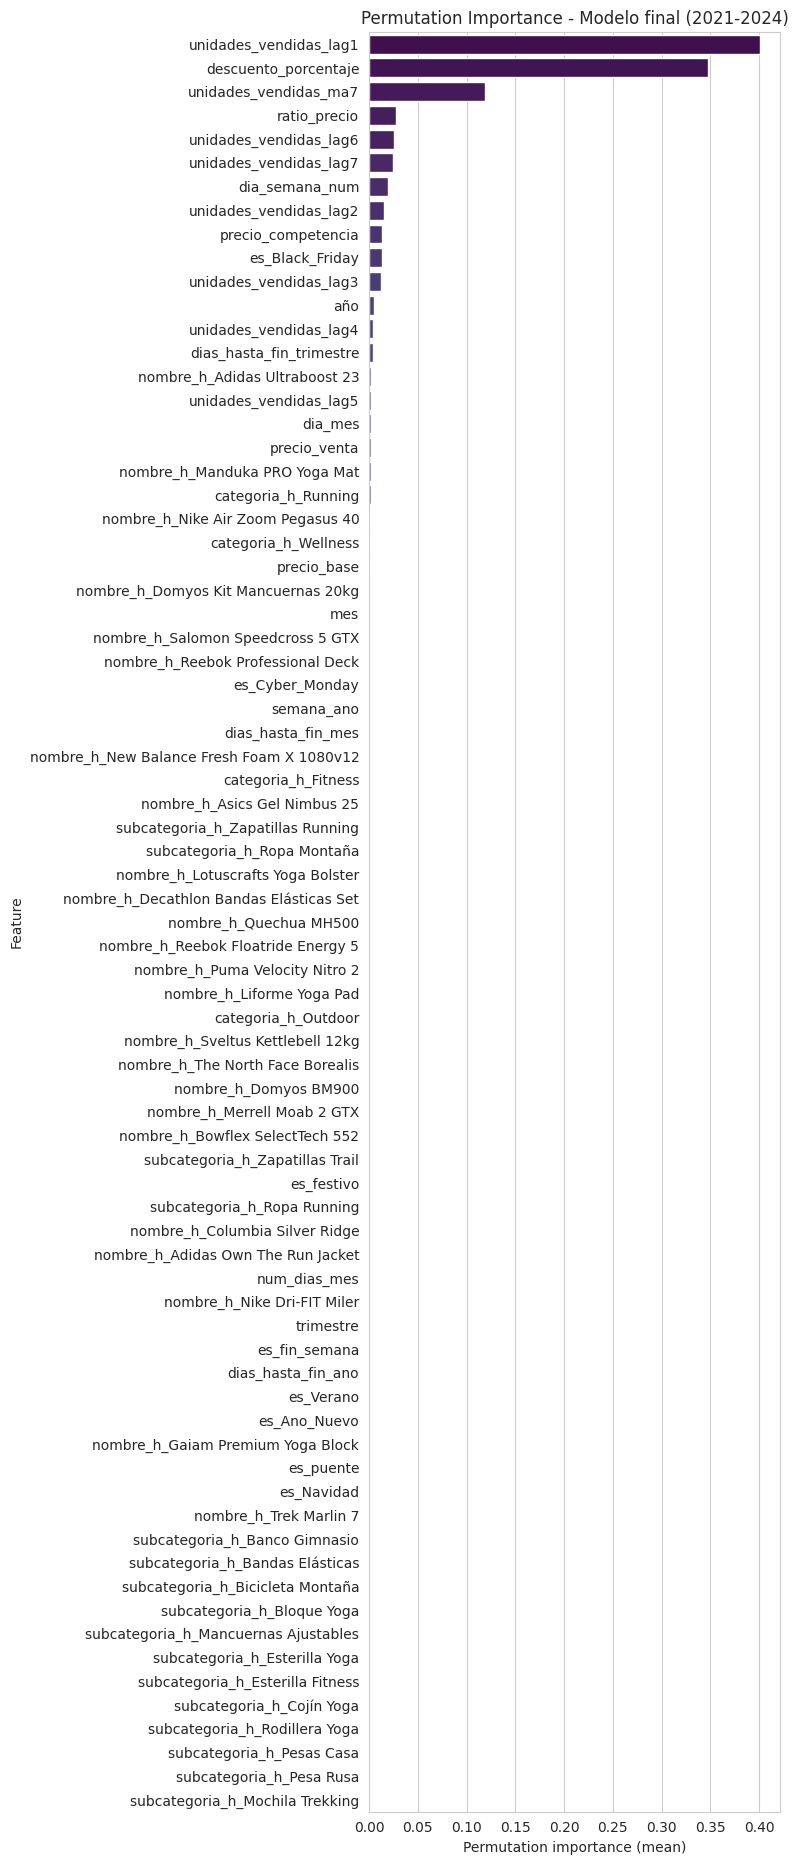

Guardado figura: ../reports/figs/permutation_importance_final.png
Guardado modelo joblib: ../models/modelo_final.joblib

✅ Permutation importance calculada y modelo guardado.


In [30]:
# 🤖 Permutation importance del modelo final y guardado como joblib
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import joblib
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

# Asegurar que existe el modelo en el namespace o intentar cargarlo desde ../models
models_dir = Path('..') / 'models'
model_joblib_path = models_dir / 'modelo_final.joblib'
model_pickle_path = models_dir / 'hgb_model_final_2021_2024.pkl'
median_path = models_dir / 'median_imputer_2021_2024.pkl'

if 'model' not in globals():
    if model_joblib_path.exists():
        model = joblib.load(model_joblib_path)
        print(f'Loaded model from {model_joblib_path}')
    elif model_pickle_path.exists():
        with open(model_pickle_path, 'rb') as f:
            model = pickle.load(f)
        print(f'Loaded model from {model_pickle_path}')
    else:
        raise NameError('No se encontró `model` en memoria ni archivos en ../models. Ejecuta la celda de reentrenamiento primero.')
else:
    print('Usando `model` ya presente en el namespace.')

# Cargar medianas/imputador si no está en memoria
if 'medianas' not in globals():
    if median_path.exists():
        with open(median_path, 'rb') as f:
            medianas = pickle.load(f)
        print(f'Loaded median imputer from {median_path}')
    else:
        # intentamos calcularlo a partir de df_processed
        if 'df_processed' not in globals():
            p = Path('..') / 'data' / 'processed' / 'df_processed.csv'
            if p.exists():
                df_processed = pd.read_csv(p)
                try:
                    df_processed['fecha'] = pd.to_datetime(df_processed['fecha'])
                except Exception:
                    pass
                print(f'Cargado df_processed desde {p} para calcular medianas')
            else:
                raise NameError('No hay `df_processed` en memoria ni ../data/processed/df_processed.csv. Ejecuta la celda de preprocesado.')
        train_full = df_processed[df_processed['año'].isin([2021,2022,2023,2024])].copy()
        numeric_cols = train_full.select_dtypes(include=[np.number]).columns.tolist()
        predictors = [c for c in numeric_cols if c not in ['unidades_vendidas','ingresos']]
        if len(predictors) == 0:
            raise ValueError('No se encontraron predictoras numéricas en df_processed para calcular medianas.')
        medianas = train_full[predictors].median()
        print('Median imputer calculado desde df_processed.')
else:
    print('Usando `medianas` presente en el namespace.')

# Preparar X,y completos para perm. importance (usamos mismo conjunto 2021-2024)
train_full = df_processed[df_processed['año'].isin([2021,2022,2023,2024])].copy()
numeric_cols = train_full.select_dtypes(include=[np.number]).columns.tolist()
predictors = [c for c in numeric_cols if c not in ['unidades_vendidas','ingresos']]
X_full = train_full[predictors].copy().fillna(medianas)
y_full = train_full['unidades_vendidas'].copy()

print(f'Calculando permutation importance sobre {X_full.shape[0]:,} filas y {X_full.shape[1]:,} features...')
try:
    r = permutation_importance(model, X_full, y_full, n_repeats=10, random_state=42, n_jobs=-1)
except Exception as e:
    raise RuntimeError(f'Error calculando permutation_importance: {e}')

imp_df = pd.DataFrame({'feature': X_full.columns, 'importance_mean': r.importances_mean, 'importance_std': r.importances_std})
imp_df = imp_df.sort_values('importance_mean', ascending=False).reset_index(drop=True)

# Mostrar top 30 features
pd.options.display.float_format = '{:,.6f}'.format
print('\nTop 30 features por permutation importance (media)')
display(imp_df.head(30))

# Gráfico: barras horizontales ordenadas (mayor a menor)
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(8, max(6, 0.25 * len(imp_df))))
sns.barplot(x='importance_mean', y='feature', data=imp_df, ax=ax, palette='viridis')
ax.set_xlabel('Permutation importance (mean)')
ax.set_ylabel('Feature')
ax.set_title('Permutation Importance - Modelo final (2021-2024)')
plt.tight_layout()
plt.show()

# Guardar figura y modelo en joblib
reports_dir = Path('..') / 'reports'
figs_dir = reports_dir / 'figs'
figs_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)
fig_path = figs_dir / 'permutation_importance_final.png'
joblib_model_path = models_dir / 'modelo_final.joblib'
try:
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    joblib.dump(model, joblib_model_path)
    print(f'Guardado figura: {fig_path}')
    print(f'Guardado modelo joblib: {joblib_model_path}')
except Exception as e:
    print(f'Advertencia: fallo al guardar figura/modelo: {e}')

print('\n✅ Permutation importance calculada y modelo guardado.')
